# Treinamento YOLOv8 OBB — Segmentação de Cartas TCG

Pipeline completo para treinar um detector **YOLOv8 Oriented Bounding Boxes (OBB)** no dataset local de cartas, avaliar as métricas de desempenho e exportar o modelo final em PyTorch (`.pt`) e ONNX (`.onnx`).

| Etapa | Objetivo |
|---|---|
| 0 | Configuração de versão e hiperparâmetros |
| 1 | Validação do ambiente (CUDA / PyTorch / Ultralytics) |
| 2 | Validação da estrutura do dataset e do `data.yaml` OBB |
| 3 | Treinamento a partir de `yolov8n-obb.pt` |
| 4 | Validação e extração das métricas OBB |
| 5 | Exibição dos gráficos gerados pelo Ultralytics |
| 6 | Renomeação de `best.pt` e exportação ONNX |


## 0. Configuração do experimento

Altere apenas `VERSION` para gerar um novo experimento. O nome do run, dos pesos e do ONNX é derivado automaticamente como `obb-{VERSION}`.


In [42]:
from __future__ import annotations

from pathlib import Path

# ---------------------------------------------------------------------------
# Identidade do experimento
# ---------------------------------------------------------------------------
VERSION = "v1"
EXPERIMENT_NAME = f"obb-{VERSION}"

# ---------------------------------------------------------------------------
# Caminhos do projeto
# ---------------------------------------------------------------------------
ROOT = Path(".").resolve()
DATASET_DIR = ROOT / "dataset"
DATA_YAML = DATASET_DIR / "data.yaml"
# Caminho absoluto: no Ultralytics 8.4, project relativo vira runs/{task}/{project}
PROJECT_DIR = ROOT / "runs" / "obb"


def bind_run_paths(run_dir: Path) -> None:
    """Atualiza RUN_DIR / WEIGHTS_DIR para a pasta real do experimento."""
    global RUN_DIR, WEIGHTS_DIR
    RUN_DIR = Path(run_dir)
    WEIGHTS_DIR = RUN_DIR / "weights"


def find_existing_run_dir() -> Path | None:
    """Localiza a pasta do experimento mesmo se o Ultralytics tiver aninhado o project."""
    names = ("best.pt", f"{EXPERIMENT_NAME}.pt", "last.pt")
    candidates = [
        PROJECT_DIR / EXPERIMENT_NAME,
        PROJECT_DIR / "runs" / "obb" / EXPERIMENT_NAME,
    ]
    for folder in candidates:
        weights = folder / "weights"
        if any((weights / name).exists() for name in names):
            return folder
    if PROJECT_DIR.exists():
        for name in names:
            for pt in PROJECT_DIR.rglob(name):
                if EXPERIMENT_NAME in pt.parts and pt.parent.name == "weights":
                    return pt.parent.parent
    return None


bind_run_paths(PROJECT_DIR / EXPERIMENT_NAME)
_existing_run = find_existing_run_dir()
if _existing_run:
    bind_run_paths(_existing_run)

# ---------------------------------------------------------------------------
# Hiperparâmetros de treinamento
# ---------------------------------------------------------------------------
PRETRAINED_MODEL = "yolov8n-obb.pt"
EPOCHS = 100
IMGSZ = 640          # imagens nativas do dataset: 512x512
BATCH = 16
PATIENCE = 20        # early stopping
SEED = 42
WORKERS = 0          # 0 evita problemas de multiprocessing no Jupyter (Windows)

print(f"Experimento : {EXPERIMENT_NAME}")
print(f"Projeto     : {PROJECT_DIR}")
print(f"Dataset     : {DATASET_DIR}")
print(f"data.yaml   : {DATA_YAML}")
print(f"Saída       : {RUN_DIR}")
print(f"Modelo      : {PRETRAINED_MODEL} | epochs={EPOCHS} | imgsz={IMGSZ} | batch={BATCH}")


Experimento : obb-v1
Projeto     : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\runs\obb
Dataset     : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\dataset
data.yaml   : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\dataset\data.yaml
Saída       : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\runs\obb\obb-v1
Modelo      : yolov8n-obb.pt | epochs=100 | imgsz=640 | batch=16


## 1. Validação do ambiente

Instala as dependências (se necessário), verifica CUDA e imprime o resumo do ambiente de execução.


In [43]:
import subprocess
import sys

REQUIRED = {
    "ultralytics": "ultralytics",
    "pandas": "pandas",
    "pyyaml": "yaml",
    "matplotlib": "matplotlib",
    "pillow": "PIL",
    "onnx": "onnx",
    "onnxsim": "onnxsim",
}
missing = []
for pip_name, module_name in REQUIRED.items():
    try:
        __import__(module_name)
    except ImportError:
        missing.append(pip_name)

if missing:
    print(f"Instalando pacotes ausentes: {missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("Todas as dependências já estão instaladas.")


Todas as dependências já estão instaladas.


In [44]:
import platform
from datetime import datetime

import pandas as pd
import torch
import ultralytics
from ultralytics import YOLO

def inspect_environment() -> pd.DataFrame:
    cuda_ok = torch.cuda.is_available()
    gpu_name = torch.cuda.get_device_name(0) if cuda_ok else "—"
    gpu_mem = (
        f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB"
        if cuda_ok
        else "—"
    )
    device = "0" if cuda_ok else "cpu"

    rows = [
        ("Data/hora", datetime.now().strftime("%Y-%m-%d %H:%M:%S")),
        ("SO", f"{platform.system()} {platform.release()}"),
        ("Python", platform.python_version()),
        ("PyTorch", torch.__version__),
        ("Ultralytics", ultralytics.__version__),
        ("CUDA disponível", cuda_ok),
        ("CUDA (compilado)", getattr(torch.version, "cuda", None) or "—"),
        ("GPU", gpu_name),
        ("VRAM", gpu_mem),
        ("Dispositivo de treino", device),
        ("cuDNN habilitado", torch.backends.cudnn.enabled if cuda_ok else False),
    ]
    df = pd.DataFrame(rows, columns=["Item", "Valor"])
    return df, device


env_df, DEVICE = inspect_environment()
display(env_df)

if DEVICE == "cpu":
    print("\n[AVISO] CUDA não detectada. O treinamento rodará em CPU e será bem mais lento.")
else:
    print(f"\nGPU pronta: {torch.cuda.get_device_name(0)}")


,Item,Valor
0,Data/hora,2026-08-25 21:00:23
1,SO,Windows 11
2,Python,3.14.7
3,PyTorch,2.11.0+cu128
4,Ultralytics,8.4.129
5,CUDA disponível,True
6,CUDA (compilado),12.8
7,GPU,NVIDIA GeForce RTX 5060
8,VRAM,8.0 GB
9,Dispositivo de treino,0



GPU pronta: NVIDIA GeForce RTX 5060


## 2. Validação do dataset e do `data.yaml`

O Ultralytics espera, para OBB:

1. Um YAML com `train` / `val` (e opcionalmente `test`), `names` e, de preferência, `path` e `nc`.
2. Labels no formato YOLO OBB: `class x1 y1 x2 y2 x3 y3 x4 y4` (coordenadas normalizadas em `[0, 1]`).
3. Pares imagem/label em `train`, `valid` e `test`.

Esta célula valida a estrutura do diretório, o conteúdo do YAML e todas as anotações OBB.


In [45]:
from __future__ import annotations

from collections import Counter

import yaml
from PIL import Image

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}


def load_yaml(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as f:
        data = yaml.safe_load(f)
    if not isinstance(data, dict):
        raise ValueError(f"{path} não contém um mapeamento YAML válido.")
    return data


def resolve_class_names(cfg: dict) -> dict[int, str]:
    names = cfg.get("names")
    if names is None:
        raise ValueError("Campo obrigatório ausente em data.yaml: 'names'.")
    if isinstance(names, dict):
        return {int(k): str(v) for k, v in names.items()}
    if isinstance(names, list):
        return {i: str(n) for i, n in enumerate(names)}
    raise ValueError(f"Formato de 'names' não suportado: {type(names)}")


def list_images(folder: Path) -> list[Path]:
    if not folder.is_dir():
        return []
    return sorted(p for p in folder.iterdir() if p.suffix.lower() in IMAGE_EXTS)


def parse_obb_line(line: str, n_classes: int) -> tuple[bool, str]:
    parts = line.strip().split()
    if not parts:
        return True, "linha vazia ignorada"
    if len(parts) != 9:
        return False, f"esperado 9 valores (class + 8 coords), obtido {len(parts)}"
    try:
        cls = int(float(parts[0]))
        coords = [float(x) for x in parts[1:]]
    except ValueError:
        return False, "valores não numéricos"
    if cls < 0 or cls >= n_classes:
        return False, f"classe {cls} fora de [0, {n_classes - 1}]"
    if any(c < -1e-3 or c > 1.0 + 1e-3 for c in coords):
        return False, f"coordenadas fora de [0, 1]: {coords}"
    return True, "ok"


def validate_split(split_dir: Path, n_classes: int, sample_limit: int | None = None) -> dict:
    images_dir = split_dir / "images"
    labels_dir = split_dir / "labels"
    images = list_images(images_dir)
    labels = sorted(labels_dir.glob("*.txt")) if labels_dir.is_dir() else []

    img_stems = {p.stem for p in images}
    lbl_stems = {p.stem for p in labels}

    n_ok, n_bad, n_objs = 0, 0, 0
    class_hist: Counter = Counter()
    errors: list[str] = []

    checked = labels if sample_limit is None else labels[:sample_limit]
    for lbl in checked:
        text = lbl.read_text(encoding="utf-8").strip()
        if not text:
            continue
        for i, line in enumerate(text.splitlines(), start=1):
            ok, msg = parse_obb_line(line, n_classes)
            if ok and msg == "ok":
                n_ok += 1
                n_objs += 1
                class_hist[int(float(line.split()[0]))] += 1
            elif not ok:
                n_bad += 1
                if len(errors) < 8:
                    errors.append(f"{lbl.name}:{i} -> {msg}")

    return {
        "images_dir": images_dir,
        "labels_dir": labels_dir,
        "n_images": len(images),
        "n_labels": len(labels),
        "missing_labels": sorted(img_stems - lbl_stems)[:8],
        "orphan_labels": sorted(lbl_stems - img_stems)[:8],
        "obb_ok": n_ok,
        "obb_bad": n_bad,
        "objects_sampled": n_objs,
        "class_hist": class_hist,
        "errors": errors,
        "sample_image": images[0] if images else None,
    }


def validate_dataset(dataset_dir: Path, yaml_path: Path) -> dict:
    report: dict = {"ok": True, "issues": []}

    if not dataset_dir.is_dir():
        raise FileNotFoundError(f"Dataset não encontrado: {dataset_dir}")
    if not yaml_path.is_file():
        raise FileNotFoundError(f"data.yaml não encontrado: {yaml_path}")

    cfg = load_yaml(yaml_path)
    names = resolve_class_names(cfg)
    n_classes = len(names)

    required = ["train", "val"]
    for key in required:
        if key not in cfg:
            report["ok"] = False
            report["issues"].append(f"Campo obrigatório ausente: '{key}'")

    if "nc" in cfg and int(cfg["nc"]) != n_classes:
        report["ok"] = False
        report["issues"].append(
            f"Inconsistência: nc={cfg['nc']} mas names tem {n_classes} classe(s)."
        )

    if "path" not in cfg:
        report["issues"].append(
            "Campo 'path' ausente (não crítico). O Ultralytics usa o diretório do YAML como raiz."
        )

    yaml_root = Path(cfg["path"]).resolve() if cfg.get("path") else yaml_path.parent.resolve()

    def split_root_from_yaml(key: str, default_images: str) -> Path:
        rel = Path(str(cfg.get(key, default_images)))
        images_dir = rel if rel.is_absolute() else (yaml_root / rel)
        return images_dir.parent if images_dir.name == "images" else images_dir

    split_map = {
        "train": split_root_from_yaml("train", "train/images"),
        "valid": split_root_from_yaml("val", "valid/images"),
        "test": split_root_from_yaml("test", "test/images"),
    }

    split_reports = {}
    for name, folder in split_map.items():
        split_reports[name] = validate_split(folder, n_classes)

    report.update(
        {
            "cfg": cfg,
            "names": names,
            "n_classes": n_classes,
            "yaml_root": yaml_root,
            "has_path": "path" in cfg,
            "has_nc": "nc" in cfg,
            "has_test": "test" in cfg,
            "splits": split_reports,
        }
    )

    for name, info in split_reports.items():
        if name in ("train", "valid") and info["n_images"] == 0:
            report["ok"] = False
            report["issues"].append(f"Split '{name}' sem imagens em {info['images_dir']}")
        if info["obb_bad"] > 0:
            report["ok"] = False
            report["issues"].append(f"Split '{name}' contém {info['obb_bad']} label(s) OBB inválido(s).")
            report["issues"].extend(info["errors"])
        if info["missing_labels"]:
            report["issues"].append(
                f"Split '{name}' com imagens sem label: {info['missing_labels']}"
            )

    return report


ds = validate_dataset(DATASET_DIR, DATA_YAML)

print("=" * 72)
print("data.yaml")
print("=" * 72)
print(DATA_YAML.read_text(encoding="utf-8"))
print()
print(f"Raiz efetiva     : {ds['yaml_root']}")
print(f"Classes (nc)     : {ds['n_classes']} -> {ds['names']}")
print(f"Campo path       : {'presente' if ds['has_path'] else 'ausente (inferido)'}")
print(f"Campo nc         : {'presente' if ds['has_nc'] else 'ausente (inferido de names)'}")
print(f"Campo test       : {'presente' if ds['has_test'] else 'ausente'}")
print()

rows = []
for split, info in ds["splits"].items():
    rows.append(
        {
                "split": split,
                "pasta": str(info["images_dir"]),
                "imagens": info["n_images"],
            "labels": info["n_labels"],
            "sem label": len(info["missing_labels"]),
            "labels órfãos": len(info["orphan_labels"]),
            "objetos (amostra)": info["objects_sampled"],
            "OBB inválidos": info["obb_bad"],
        }
    )

display(pd.DataFrame(rows).set_index("split"))

if ds["issues"]:
    print("\nObservações:")
    for issue in ds["issues"]:
        print(f"  - {issue}")

if not ds["ok"]:
    raise RuntimeError("Validação do dataset falhou. Corrija os problemas acima antes de treinar.")

print("\nDataset válido para treinamento YOLOv8 OBB.")


data.yaml
train: train/images
val: valid/images
test: test/images

names: 
  0: card

Raiz efetiva     : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\dataset
Classes (nc)     : 1 -> {0: 'card'}
Campo path       : ausente (inferido)
Campo nc         : ausente (inferido de names)
Campo test       : presente



,pasta,imagens,labels,sem label,labels órfãos,objetos (amostra),OBB inválidos
split,,,,,,,
train,C:\Users\Pichau\Documents\Repositorios\TCGTrad...,110,110,0,0,893,0
valid,C:\Users\Pichau\Documents\Repositorios\TCGTrad...,31,31,0,0,236,0
test,C:\Users\Pichau\Documents\Repositorios\TCGTrad...,15,15,0,0,123,0



Observações:
  - Campo 'path' ausente (não crítico). O Ultralytics usa o diretório do YAML como raiz.

Dataset válido para treinamento YOLOv8 OBB.


### Amostra visual de anotações OBB

Desenha os polígonos de 4 pontos de uma imagem de treino para confirmar que as caixas orientadas estão alinhadas às cartas.


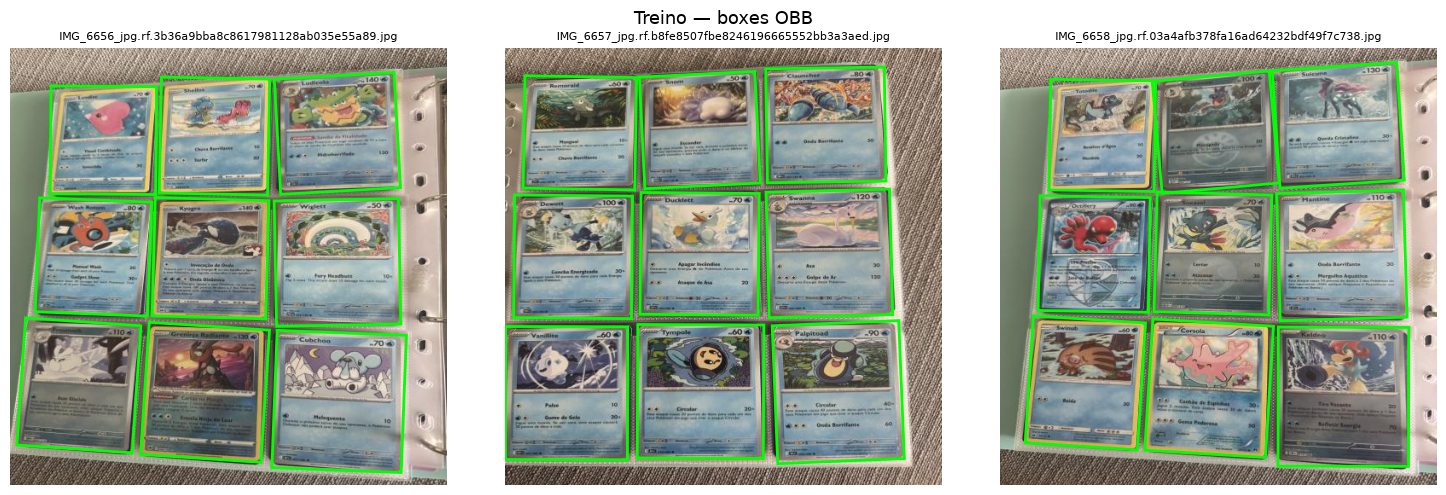

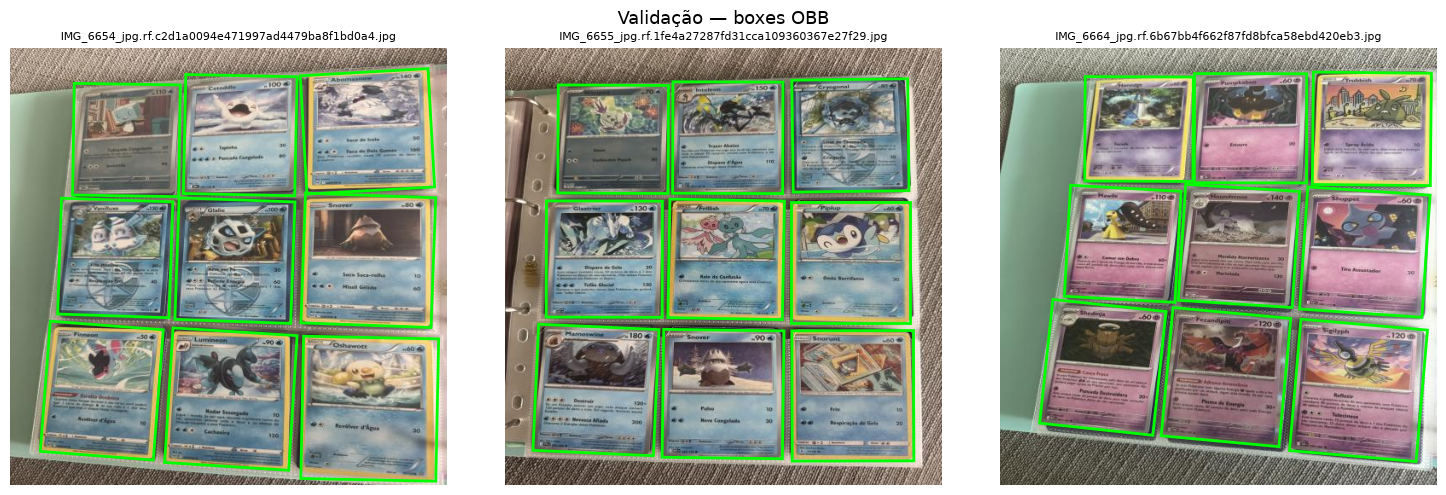

In [46]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon


def load_obb_polygons(label_path: Path, img_w: int, img_h: int) -> list[np.ndarray]:
    polys = []
    text = label_path.read_text(encoding="utf-8").strip()
    if not text:
        return polys
    for line in text.splitlines():
        parts = line.split()
        if len(parts) != 9:
            continue
        coords = np.array([float(x) for x in parts[1:]], dtype=float).reshape(4, 2)
        coords[:, 0] *= img_w
        coords[:, 1] *= img_h
        polys.append(coords)
    return polys


def show_obb_samples(split_dir: Path, n: int = 3, title: str = "Amostras OBB") -> None:
    images = list_images(split_dir / "images")[:n]
    if not images:
        print(f"Nenhuma imagem em {split_dir / 'images'}")
        return

    fig, axes = plt.subplots(1, len(images), figsize=(5 * len(images), 5))
    if len(images) == 1:
        axes = [axes]

    for ax, img_path in zip(axes, images):
        img = Image.open(img_path).convert("RGB")
        w, h = img.size
        label_path = split_dir / "labels" / f"{img_path.stem}.txt"
        ax.imshow(img)
        if label_path.exists():
            for poly in load_obb_polygons(label_path, w, h):
                ax.add_patch(
                    Polygon(poly, closed=True, fill=False, edgecolor="lime", linewidth=2)
                )
        ax.set_title(img_path.name, fontsize=8)
        ax.axis("off")

    fig.suptitle(title, fontsize=13)
    fig.tight_layout()
    plt.show()


show_obb_samples(DATASET_DIR / "train", n=3, title="Treino — boxes OBB")
show_obb_samples(DATASET_DIR / "valid", n=3, title="Validação — boxes OBB")


## 3. Treinamento

Carrega o checkpoint pré-treinado `yolov8n-obb.pt` (DOTAv1) e treina no dataset local.

- `project` absoluto em `runs/obb` (evita o aninhamento `runs/obb/runs/obb` do Ultralytics 8.4)
- `name=f'obb-{VERSION}'` → pasta `runs/obb/obb-v1/`
- `exist_ok=True` mantém o nome exato do experimento (não cria `obb-v12`, `obb-v13`, …)


In [47]:
print(f"Iniciando treinamento: {EXPERIMENT_NAME}")
print(f"Dispositivo: {DEVICE} | modelo: {PRETRAINED_MODEL}")

model = YOLO(PRETRAINED_MODEL)

train_results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    project=str(PROJECT_DIR),
    name=EXPERIMENT_NAME,
    exist_ok=True,
    patience=PATIENCE,
    seed=SEED,
    workers=WORKERS,
    pretrained=True,
    plots=True,
    val=True,
    verbose=True,
)

save_dir = Path(model.trainer.save_dir)
bind_run_paths(save_dir)

print("\nTreinamento concluído.")
print(f"Run dir : {RUN_DIR}")
print(f"Weights : {WEIGHTS_DIR}")


Iniciando treinamento: obb-v1
Dispositivo: 0 | modelo: yolov8n-obb.pt
Ultralytics 8.4.129  Python-3.14.7 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060, 8150MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\dataset\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_de

## 4. Avaliação e métricas

Executa `model.val()` no split de validação e extrai as métricas OBB solicitadas:

- Globais: `mAP50`, `mAP50-95`, `mAP75`, Precision, Recall
- Por classe: Precision, Recall, AP50, AP50-95
- Perdas de validação: Box, Class, DFL e Angle (quando disponível)


In [48]:
found_run = find_existing_run_dir()
if found_run:
    bind_run_paths(found_run)

ckpt_path = next(
    (
        path
        for path in (
            WEIGHTS_DIR / "best.pt",
            WEIGHTS_DIR / f"{EXPERIMENT_NAME}.pt",
            WEIGHTS_DIR / "last.pt",
        )
        if path.exists()
    ),
    None,
)
if ckpt_path is None:
    raise FileNotFoundError(
        f"Pesos não encontrados em {WEIGHTS_DIR}. "
        "Rode a célula de treinamento antes da validação."
    )

print(f"Validando {ckpt_path} ...")
val_model = YOLO(str(ckpt_path))
metrics = val_model.val(
    data=str(DATA_YAML),
    split="val",
    imgsz=IMGSZ,
    device=DEVICE,
    project=str(PROJECT_DIR),
    name=EXPERIMENT_NAME,
    exist_ok=True,
    plots=True,
    workers=WORKERS,
    verbose=True,
)

print("Validação concluída.")
print(f"Run dir : {RUN_DIR}")


Validando C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\runs\obb\obb-v1\weights\best.pt ...
Ultralytics 8.4.129  Python-3.14.7 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060, 8150MiB)
YOLOv8n-obb summary (fused): 82 layers, 3,077,414 parameters, 0 gradients, 8.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 622.6103.0 MB/s, size: 53.5 KB)
val: Scanning C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\dataset\valid\labels.cache... 31 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 31/31 13.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 3.0it/s 0.7s0.9s
                   all         31        236      0.983      0.996      0.994      0.985
Speed: 0.5ms preprocess, 4.6ms inference, 0.0ms loss, 5.9ms postprocess per image
Results saved to C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\runs\obb\obb-v1
Validação concluída.
Run dir : C:\Users\Pichau\Documents\Repos

In [49]:
from typing import Any

import numpy as np


def _to_float(value: Any) -> float | None:
    if value is None:
        return None
    if isinstance(value, (float, int)):
        return float(value)
    if isinstance(value, (list, tuple)) and value:
        arr = np.asarray(value, dtype=float)
        return float(arr.mean())
    if isinstance(value, np.ndarray):
        if value.size == 0:
            return None
        return float(value.mean()) if value.ndim else float(value)
    if torch.is_tensor(value):
        return float(value.detach().cpu().mean())
    try:
        return float(value)
    except (TypeError, ValueError):
        return None


def _to_list(value: Any) -> list[float]:
    if value is None:
        return []
    if torch.is_tensor(value):
        value = value.detach().cpu().numpy()
    arr = np.asarray(value, dtype=float).reshape(-1)
    return [float(x) for x in arr]


def get_obb_namespace(metrics_obj) -> Any:
    """Ultralytics expõe métricas OBB em .obb; algumas versões reutilizam .box."""
    if hasattr(metrics_obj, "obb") and metrics_obj.obb is not None:
        ns = metrics_obj.obb
        if _to_float(getattr(ns, "map", None)) is not None:
            return ns, "obb"
    if hasattr(metrics_obj, "box") and metrics_obj.box is not None:
        return metrics_obj.box, "box"
    raise AttributeError("Não foi possível localizar metrics.obb nem metrics.box.")


def extract_global_metrics(metrics_obj, class_names: dict[int, str]) -> pd.DataFrame:
    ns, source = get_obb_namespace(metrics_obj)
    print(f"Namespace de métricas: metrics.{source}")

    mapping = [
        ("mAP50-95", "map", "metrics.obb.map — mAP@0.50:0.95"),
        ("mAP50", "map50", "metrics.obb.map50 — mAP@0.50"),
        ("mAP75", "map75", "metrics.obb.map75 — mAP@0.75"),
        ("Precision (mp)", "mp", "metrics.obb.mp — Mean Precision"),
        ("Recall (mr)", "mr", "metrics.obb.mr — Mean Recall"),
    ]

    rows = []
    for label, attr, desc in mapping:
        value = _to_float(getattr(ns, attr, None))
        rows.append({"Métrica": label, "Valor": value, "Origem": desc})
    return pd.DataFrame(rows)


def extract_per_class_metrics(metrics_obj, class_names: dict[int, str]) -> pd.DataFrame:
    ns, _ = get_obb_namespace(metrics_obj)
    p = _to_list(getattr(ns, "p", None))
    r = _to_list(getattr(ns, "r", None))
    ap50 = _to_list(getattr(ns, "ap50", None))
    ap = _to_list(getattr(ns, "ap", None))
    maps = _to_list(getattr(ns, "maps", None))

    n = max(len(class_names), len(p), len(r), len(ap50), len(ap), len(maps))
    rows = []
    for i in range(n):
        rows.append(
            {
                "Classe": class_names.get(i, str(i)),
                "Precision": p[i] if i < len(p) else None,
                "Recall": r[i] if i < len(r) else None,
                "AP50": ap50[i] if i < len(ap50) else None,
                "AP50-95": ap[i] if i < len(ap) else (maps[i] if i < len(maps) else None),
            }
        )
    return pd.DataFrame(rows)


def extract_val_losses(run_dir: Path) -> pd.DataFrame:
    csv_path = run_dir / "results.csv"
    if not csv_path.exists():
        return pd.DataFrame(columns=["Perda", "Valor", "Coluna"])

    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]
    last = df.iloc[-1]

    wanted = [
        ("Box Loss", ["val/box_loss", "metrics/box_loss"]),
        ("Class Loss", ["val/cls_loss", "metrics/cls_loss"]),
        ("DFL Loss", ["val/dfl_loss", "metrics/dfl_loss"]),
        ("Angle Loss", ["val/angle_loss", "metrics/angle_loss", "train/angle_loss"]),
    ]

    rows = []
    for label, candidates in wanted:
        col = next((c for c in candidates if c in df.columns), None)
        value = float(last[col]) if col is not None else None
        rows.append({"Perda": label, "Valor": value, "Coluna": col or "não disponível nesta versão"})
    return pd.DataFrame(rows)


CLASS_NAMES = ds["names"]

print("=" * 72)
print(f"Métricas globais OBB — {EXPERIMENT_NAME}")
print("=" * 72)
global_df = extract_global_metrics(metrics, CLASS_NAMES)
global_df["Valor"] = global_df["Valor"].map(lambda x: None if x is None else round(x, 4))
display(global_df)

print("\nMétricas por classe")
per_class_df = extract_per_class_metrics(metrics, CLASS_NAMES)
for col in ("Precision", "Recall", "AP50", "AP50-95"):
    if col in per_class_df.columns:
        per_class_df[col] = per_class_df[col].map(lambda x: None if x is None else round(x, 4))
display(per_class_df)

print("\nPerdas de validação (última época em results.csv)")
loss_df = extract_val_losses(RUN_DIR)
loss_df["Valor"] = loss_df["Valor"].map(lambda x: None if x is None else round(x, 4))
display(loss_df)

print("\nResumo formatado")
g = {row["Métrica"]: row["Valor"] for _, row in global_df.iterrows()}
l = {row["Perda"]: row["Valor"] for _, row in loss_df.iterrows()}
print(f"  mAP50      = {g.get('mAP50')}")
print(f"  mAP50-95   = {g.get('mAP50-95')}")
print(f"  Precision  = {g.get('Precision (mp)')}")
print(f"  Recall     = {g.get('Recall (mr)')}")
print(f"  Box Loss   = {l.get('Box Loss')}")
print(f"  Class Loss = {l.get('Class Loss')}")
print(f"  Angle Loss = {l.get('Angle Loss')}")


Métricas globais OBB — obb-v1
Namespace de métricas: metrics.box


,Métrica,Valor,Origem
0,mAP50-95,0.9848,metrics.obb.map — mAP@0.50:0.95
1,mAP50,0.9942,metrics.obb.map50 — mAP@0.50
2,mAP75,0.9942,metrics.obb.map75 — mAP@0.75
3,Precision (mp),0.9829,metrics.obb.mp — Mean Precision
4,Recall (mr),0.9958,metrics.obb.mr — Mean Recall



Métricas por classe


,Classe,Precision,Recall,AP50,AP50-95
0,card,0.9829,0.9958,0.9942,0.9848



Perdas de validação (última época em results.csv)


,Perda,Valor,Coluna
0,Box Loss,0.2124,val/box_loss
1,Class Loss,0.2430,val/cls_loss
2,DFL Loss,1.1939,val/dfl_loss
3,Angle Loss,0.0151,val/angle_loss



Resumo formatado
  mAP50      = 0.9942
  mAP50-95   = 0.9848
  Precision  = 0.9829
  Recall     = 0.9958
  Box Loss   = 0.2124
  Class Loss = 0.243
  Angle Loss = 0.0151


## 5. Gráficos e artefatos visuais

Exibe os arquivos gerados pelo Ultralytics no diretório do experimento:

- `confusion_matrix.png`
- `F1_curve.png`
- `PR_curve.png`
- `val_batch*_labels.jpg` / `val_batch*_pred.jpg`


Artefatos em: C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\runs\obb\obb-v1

Matriz de confusão  →  C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\runs\obb\obb-v1\confusion_matrix.png


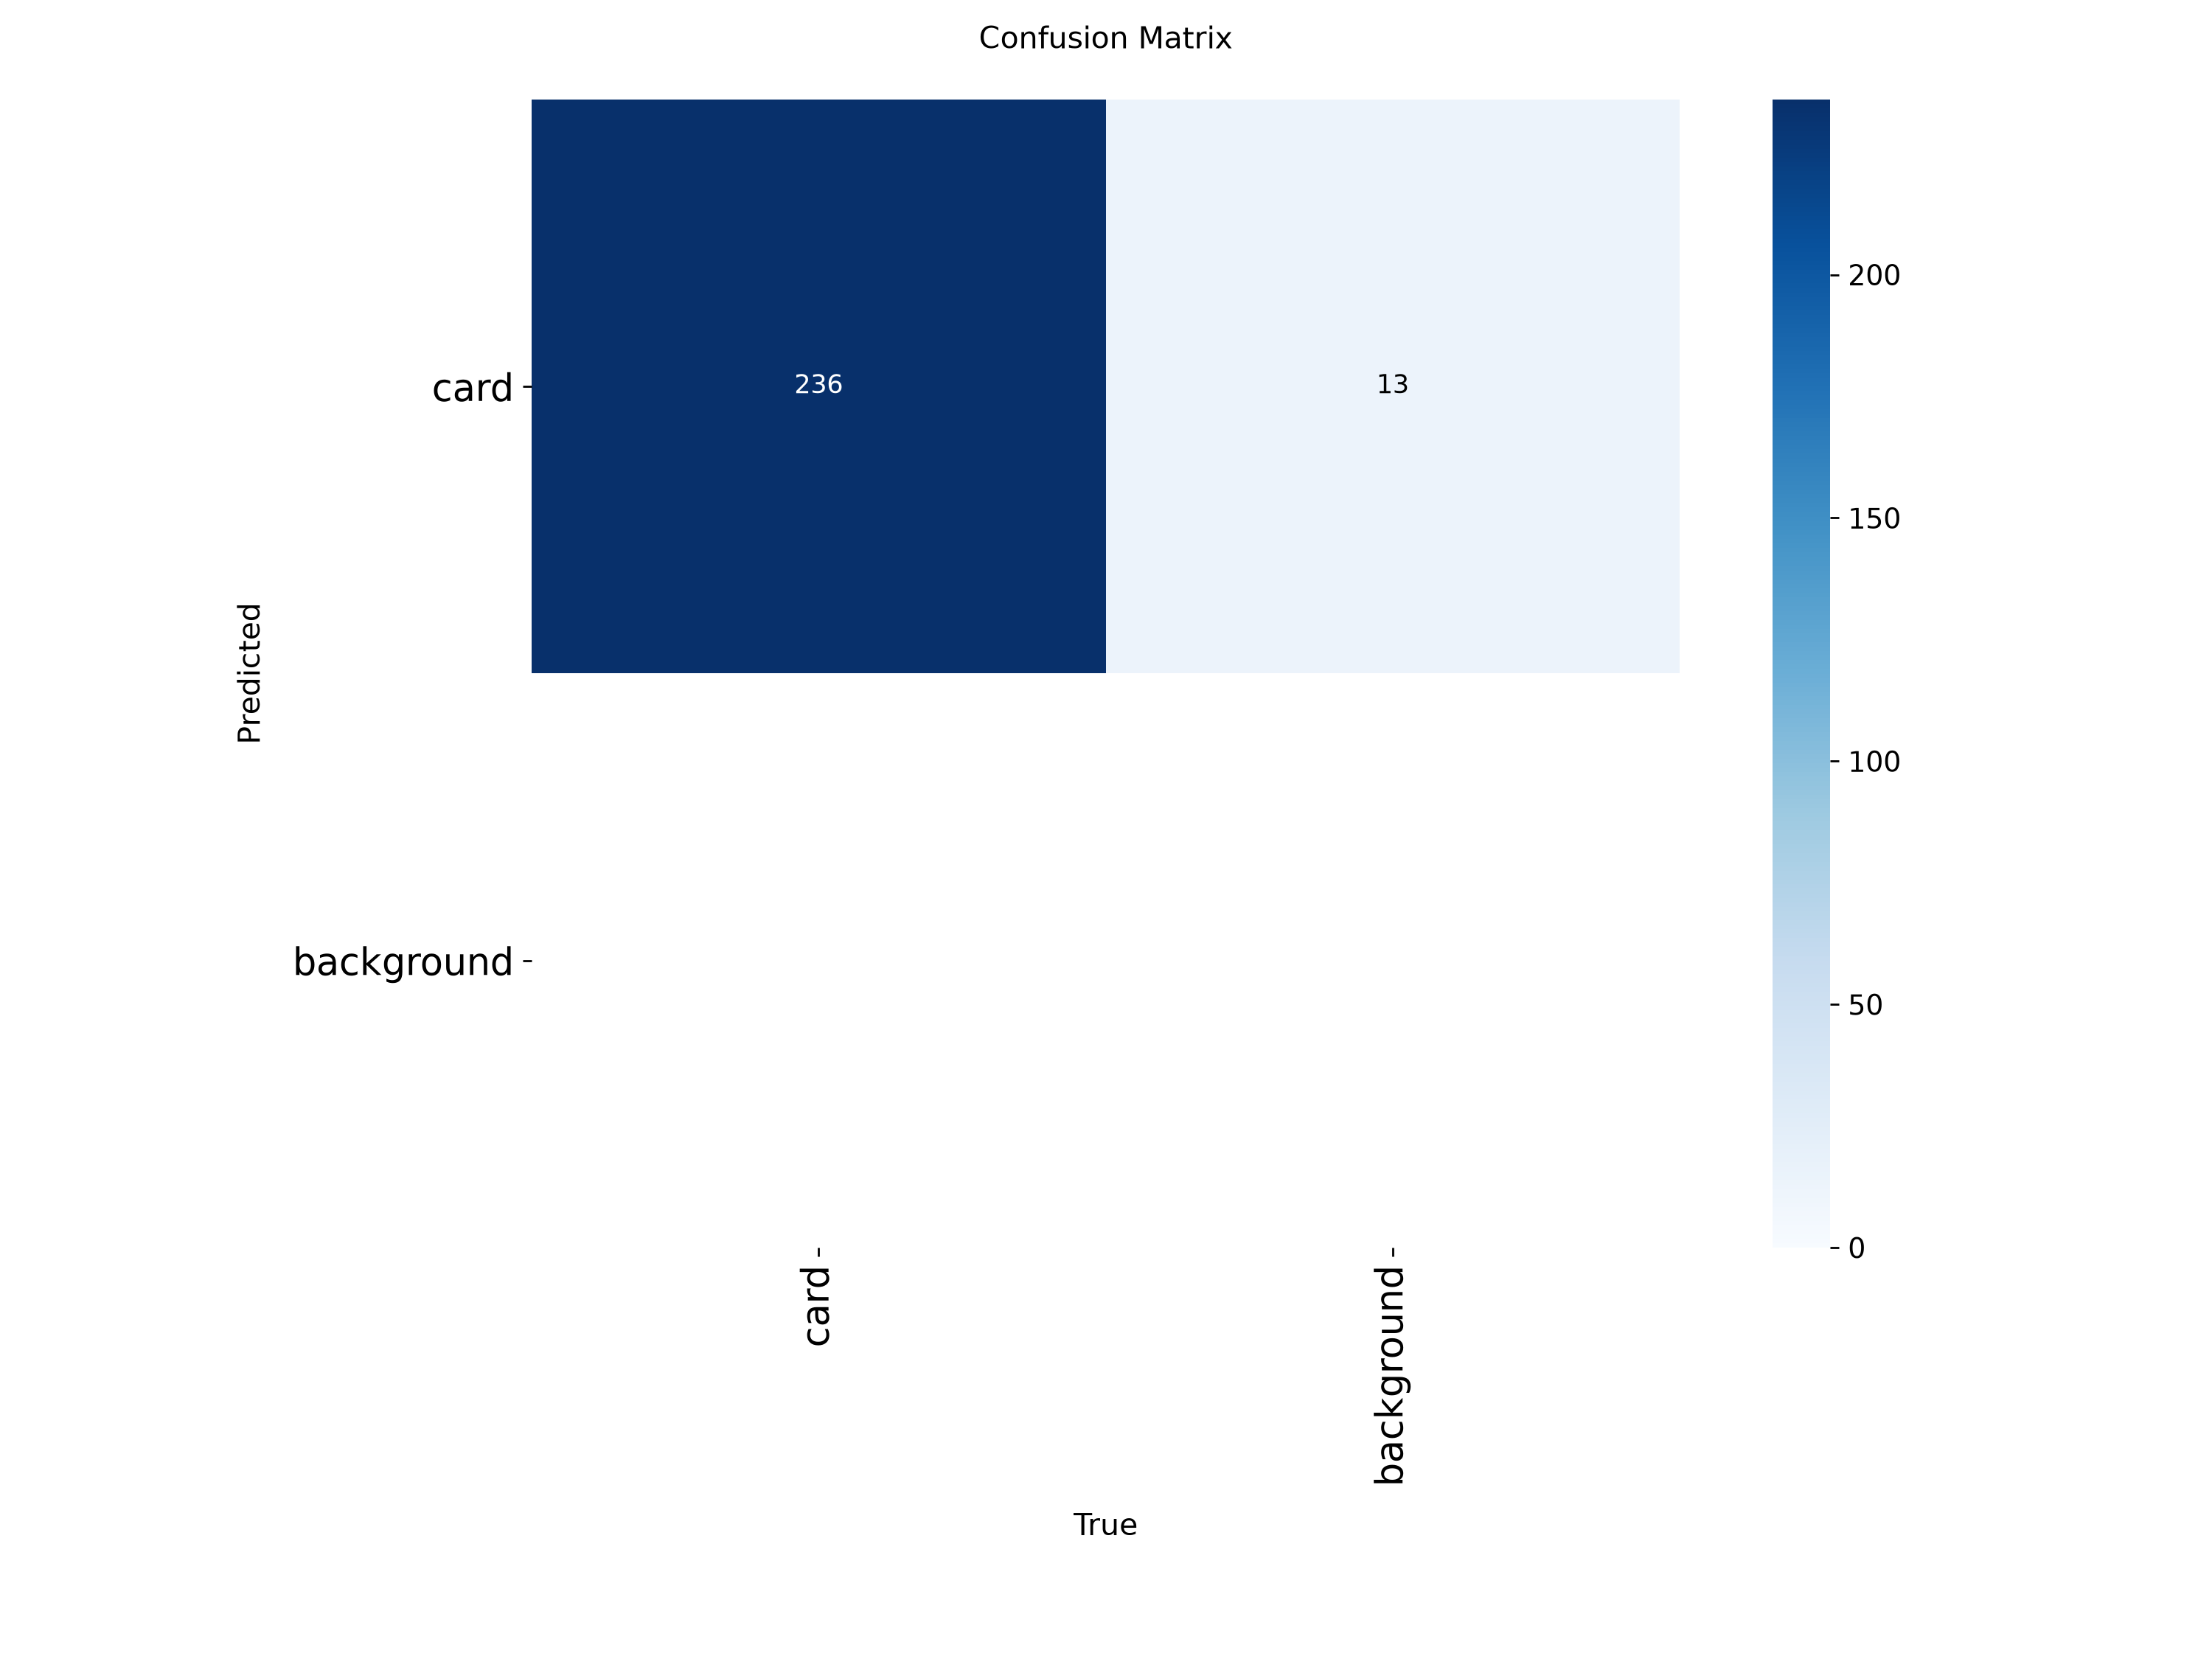

Matriz de confusão (normalizada)  →  C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\runs\obb\obb-v1\confusion_matrix_normalized.png


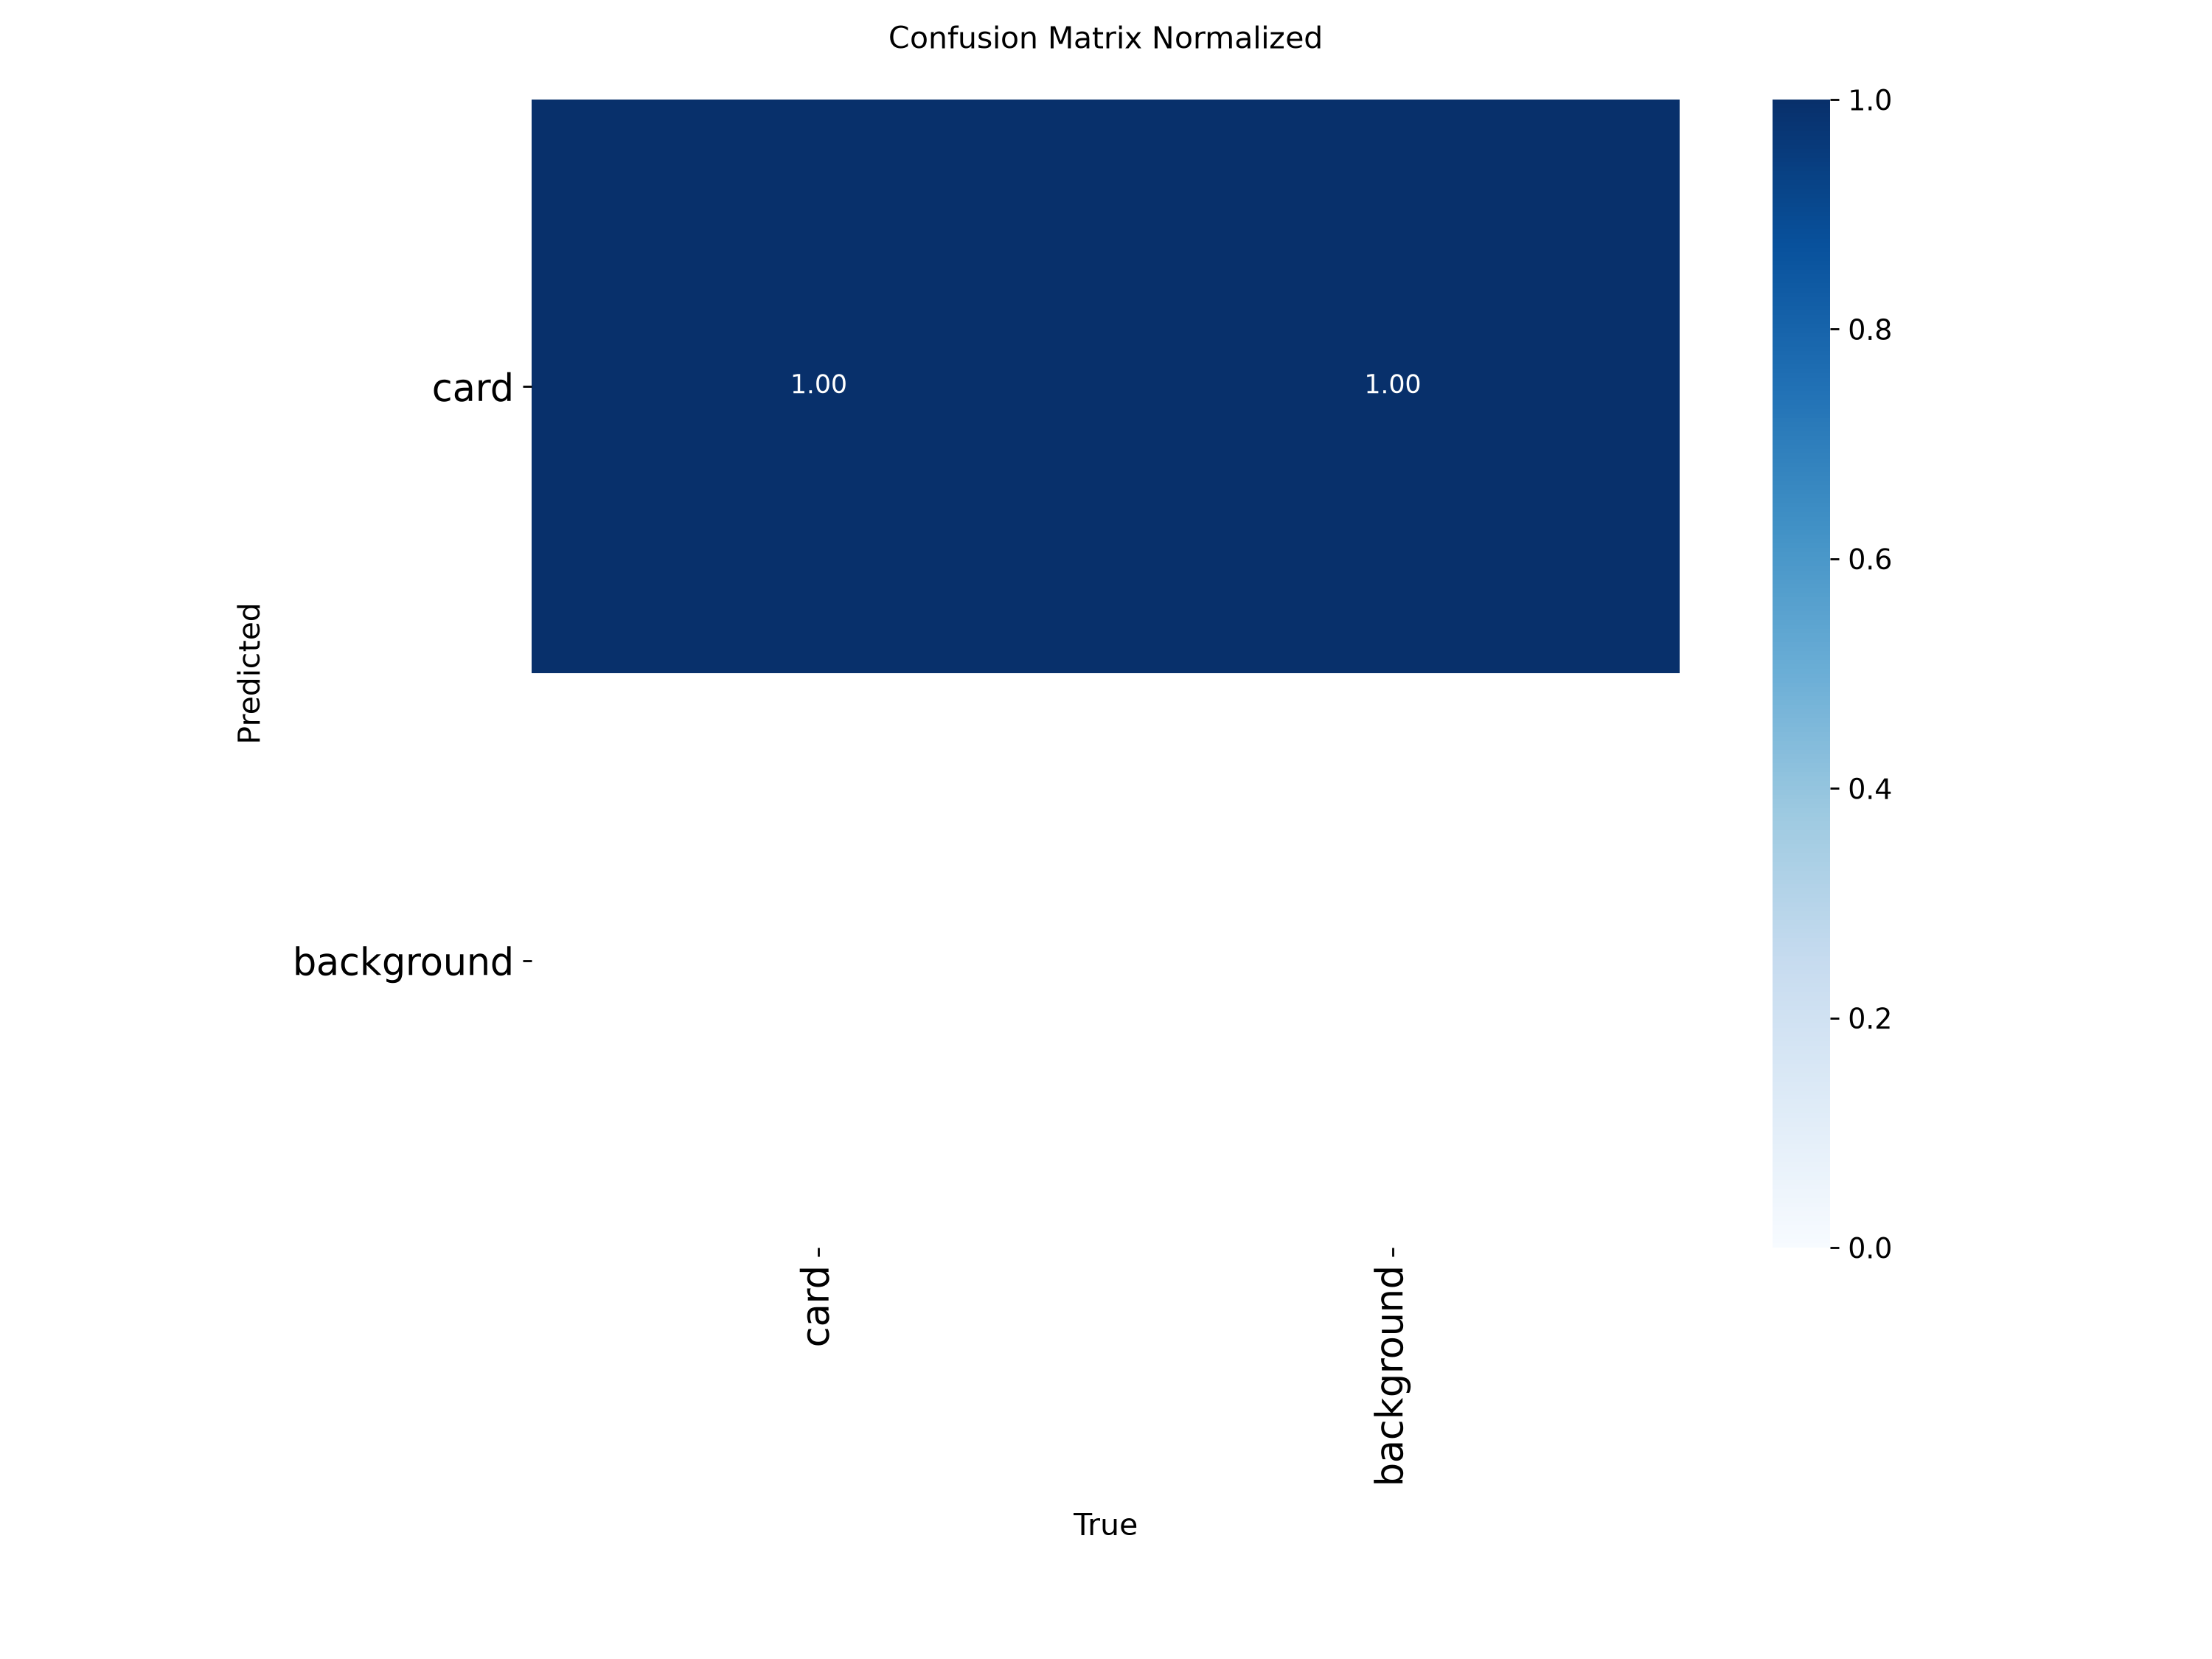

Curva F1 vs Confidence  →  C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\runs\obb\obb-v1\BoxF1_curve.png


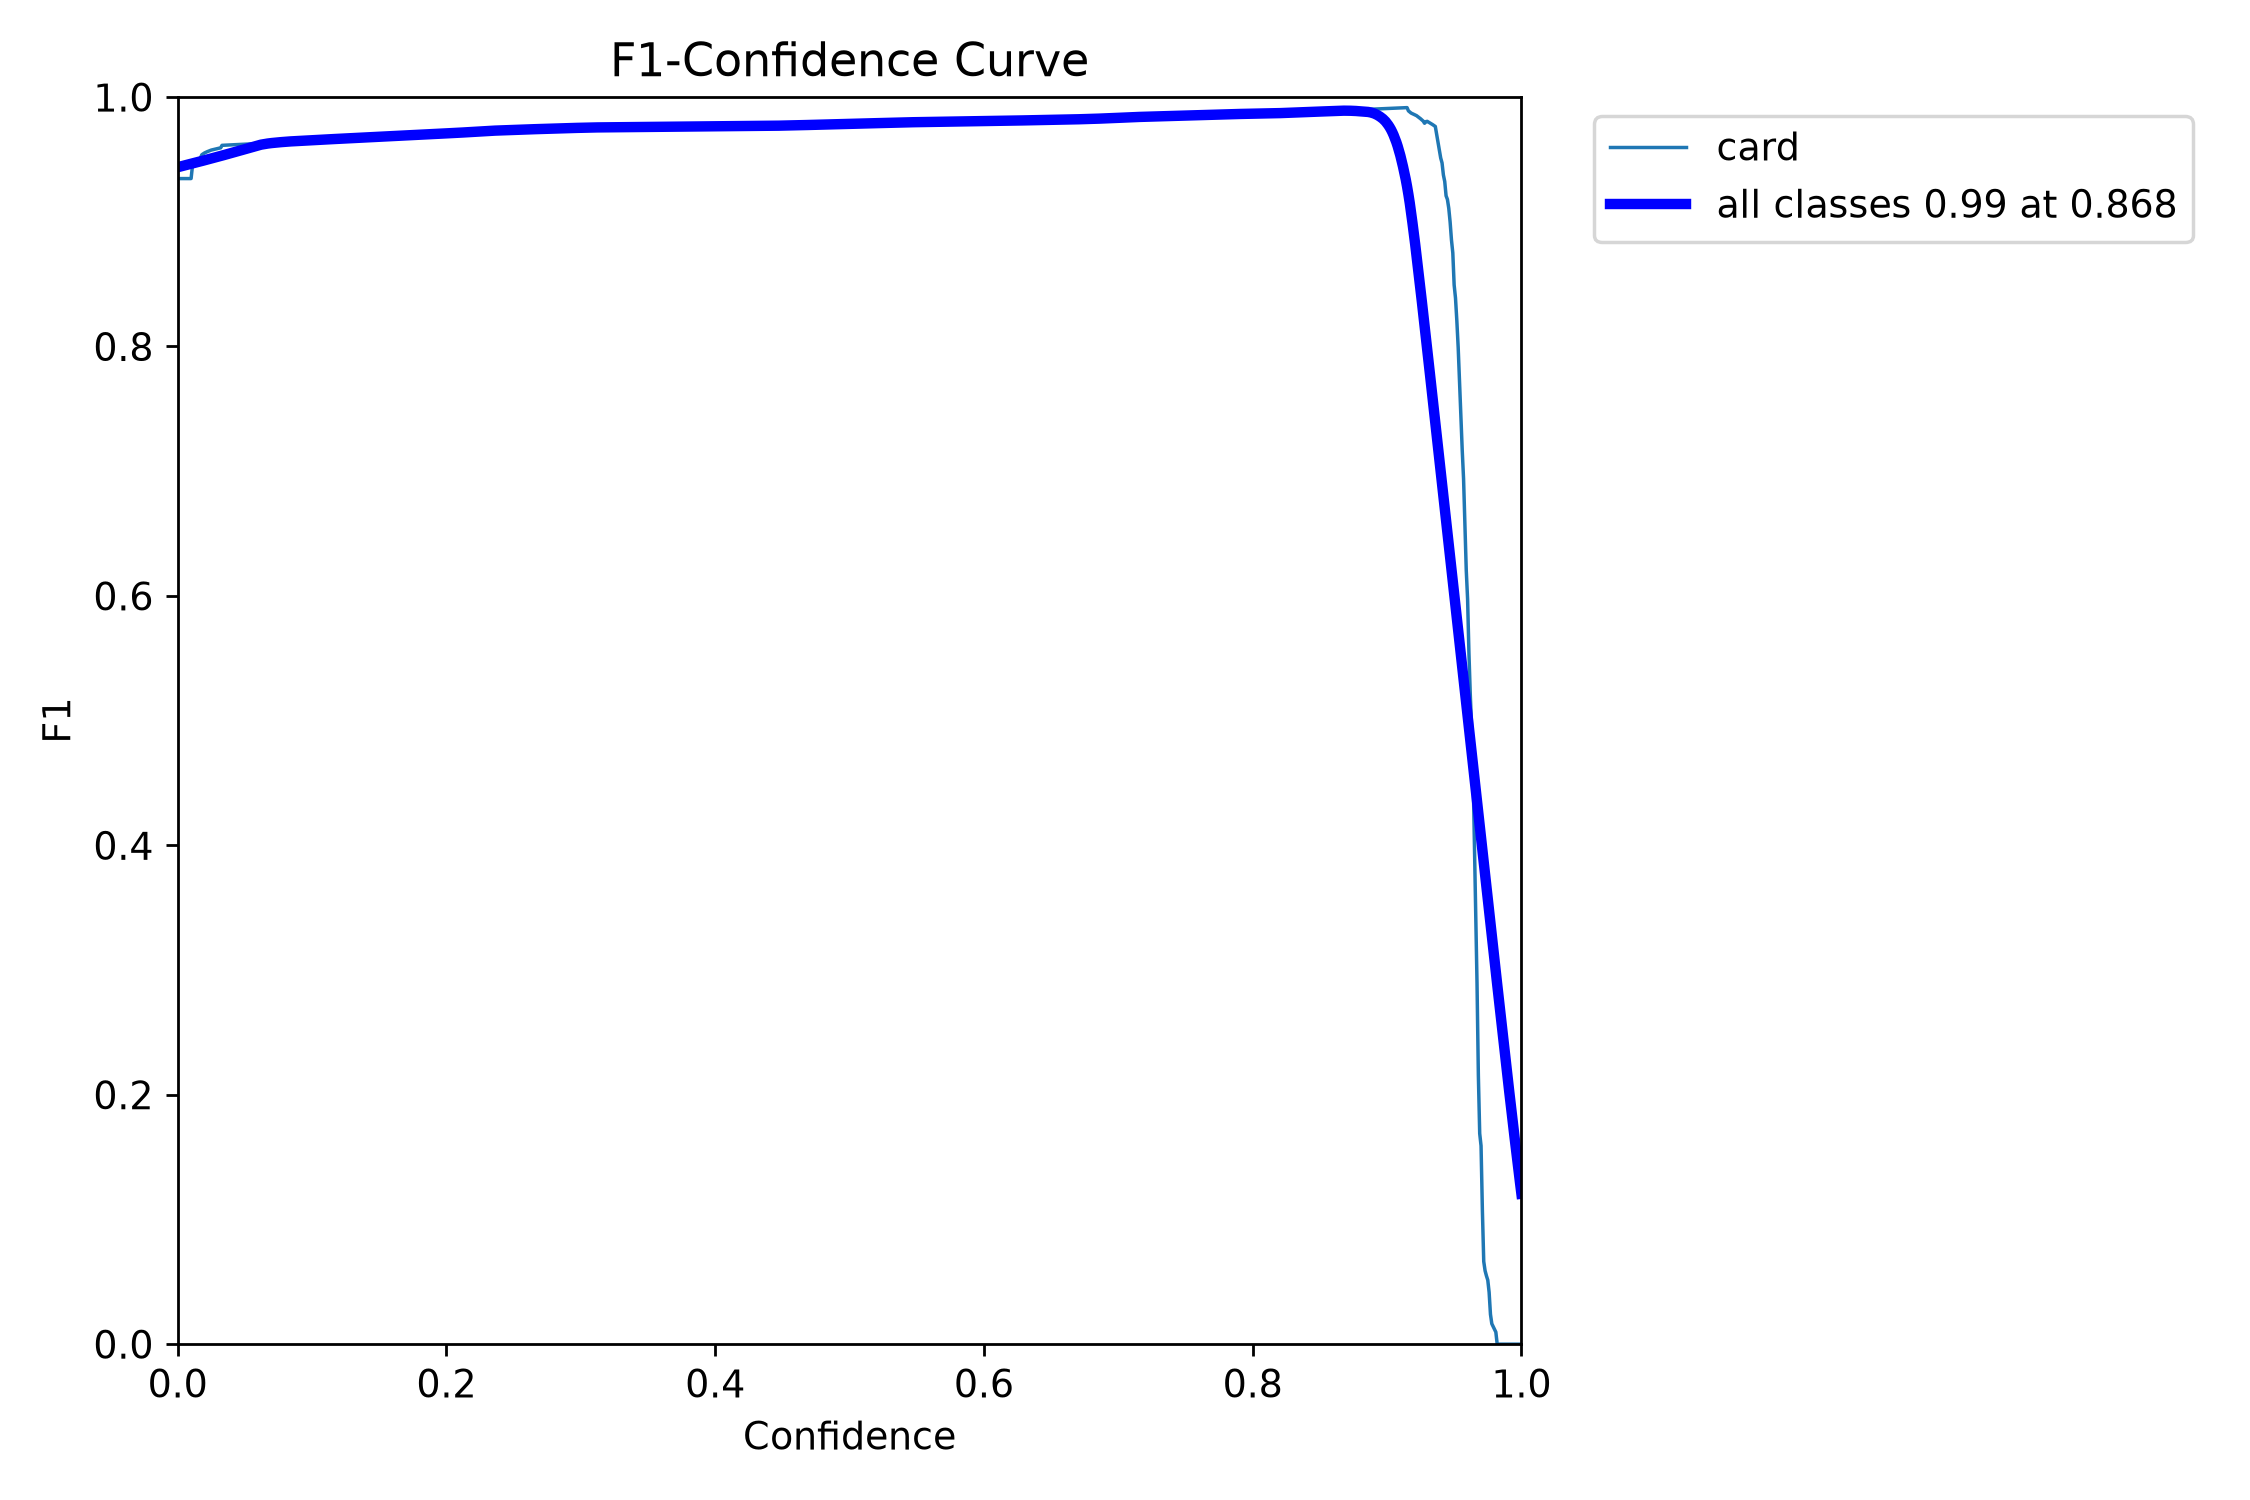

Curva Precision–Recall  →  C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\runs\obb\obb-v1\BoxPR_curve.png


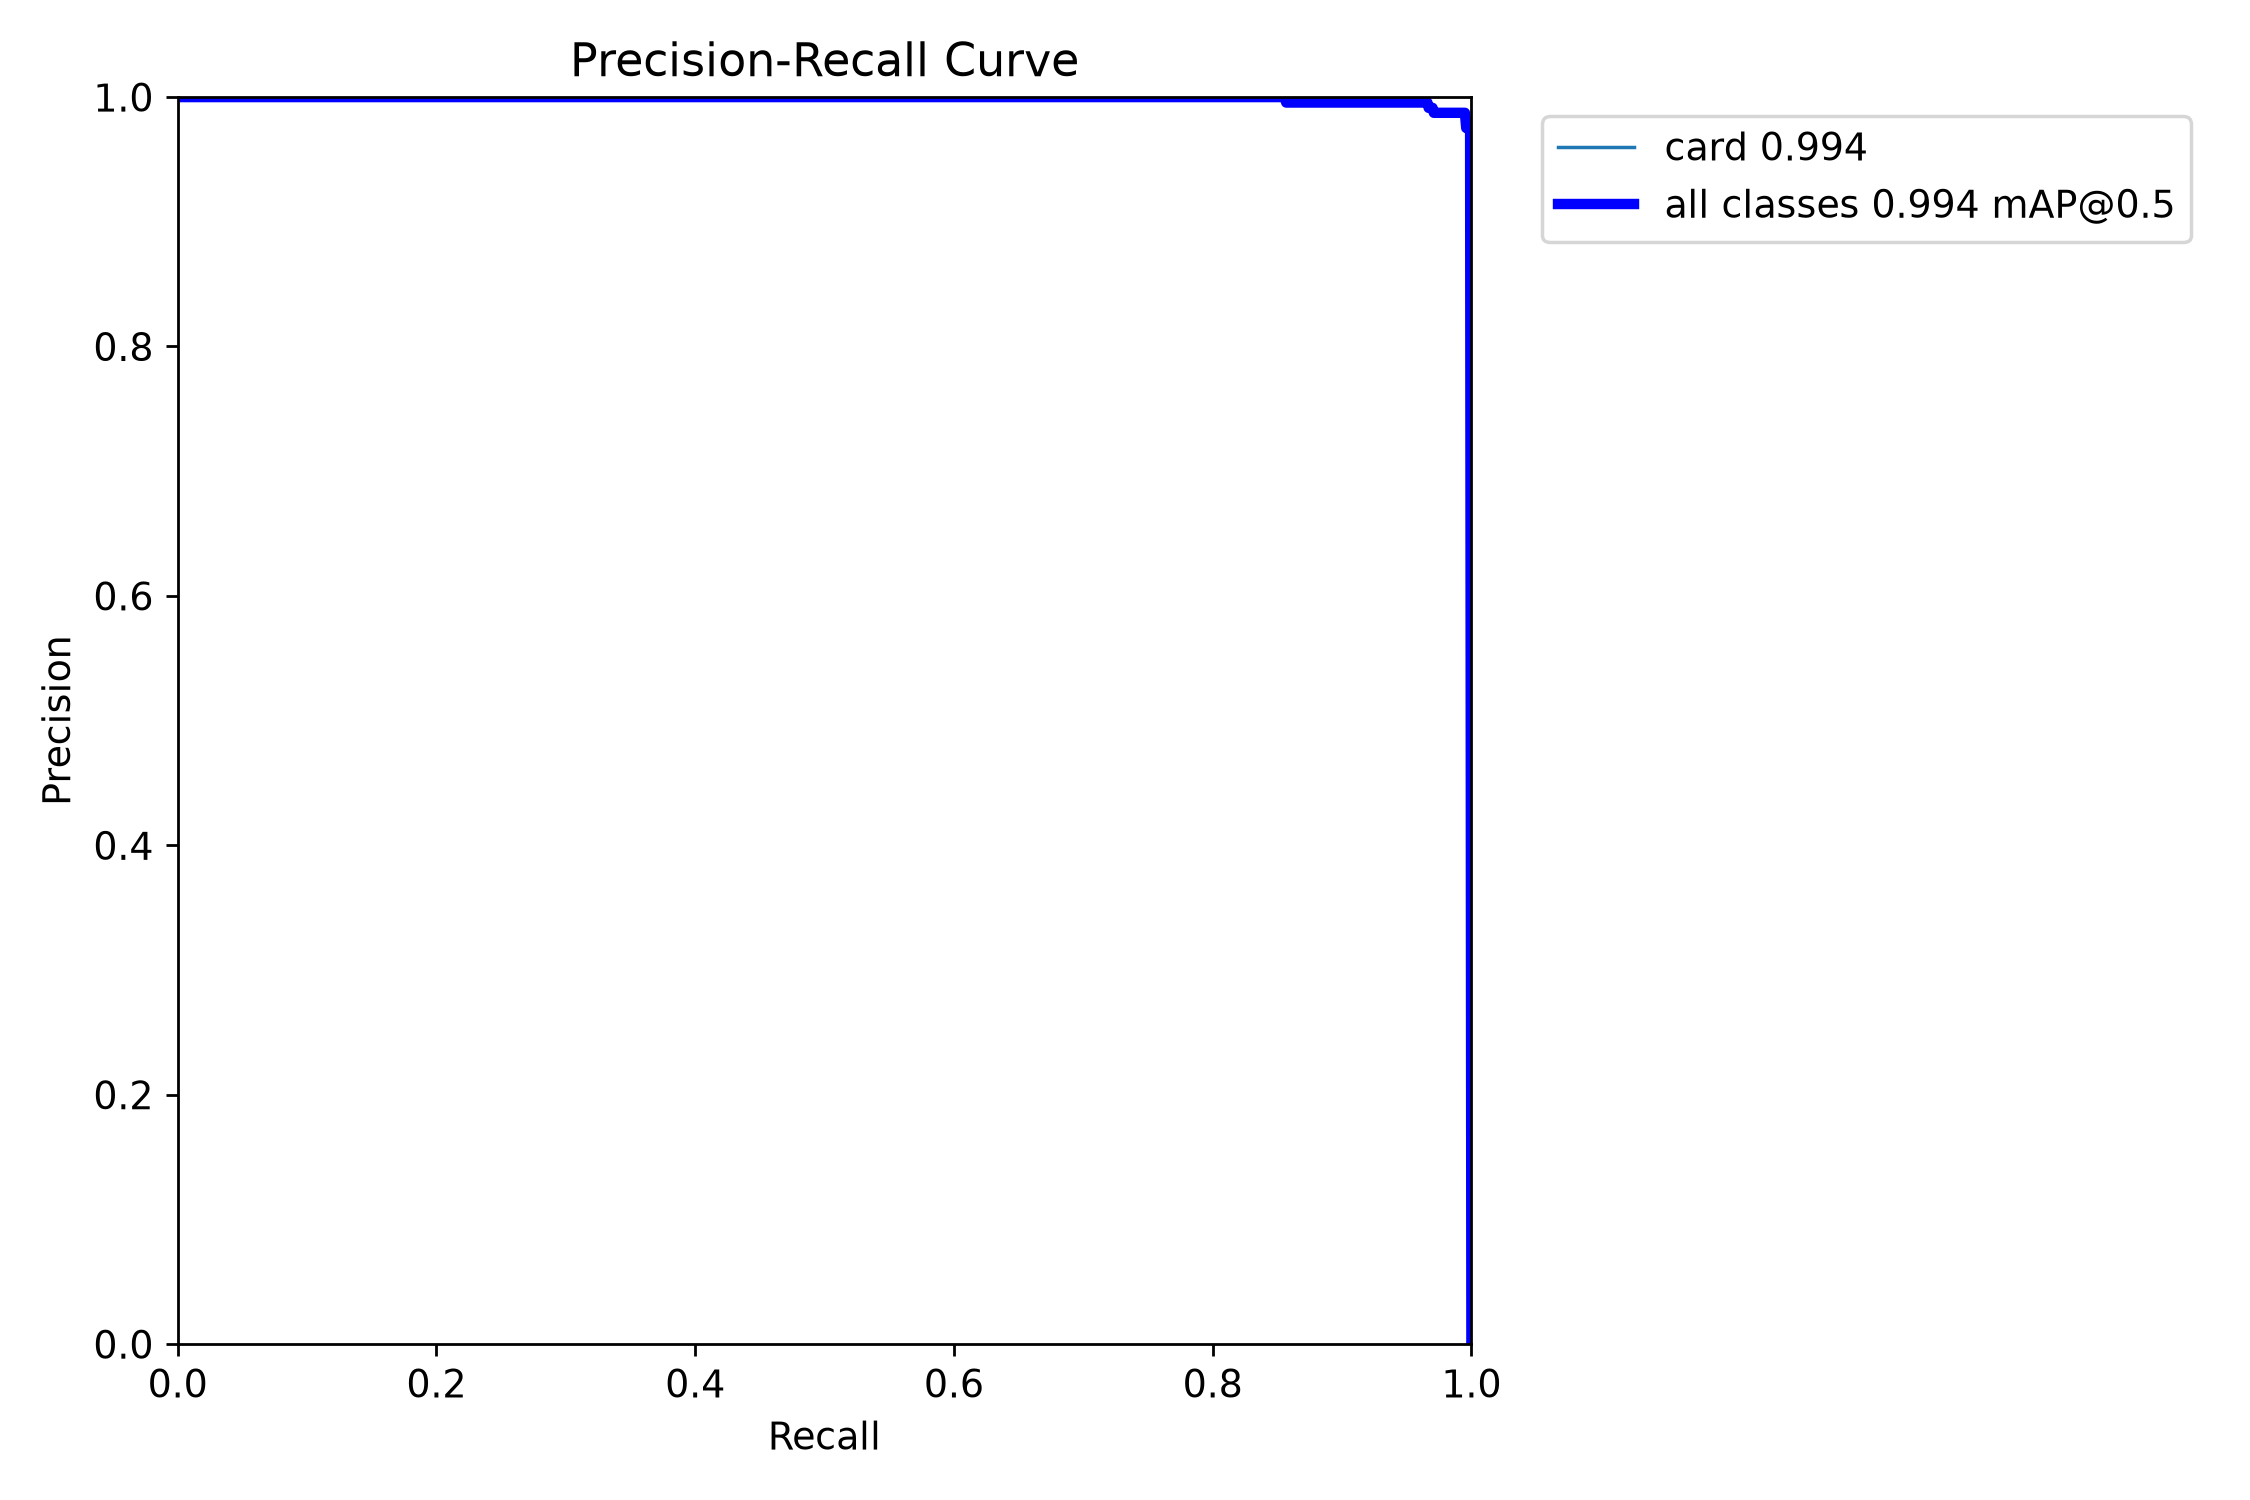

Curvas de treino (results.png)  →  C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\runs\obb\obb-v1\results.png


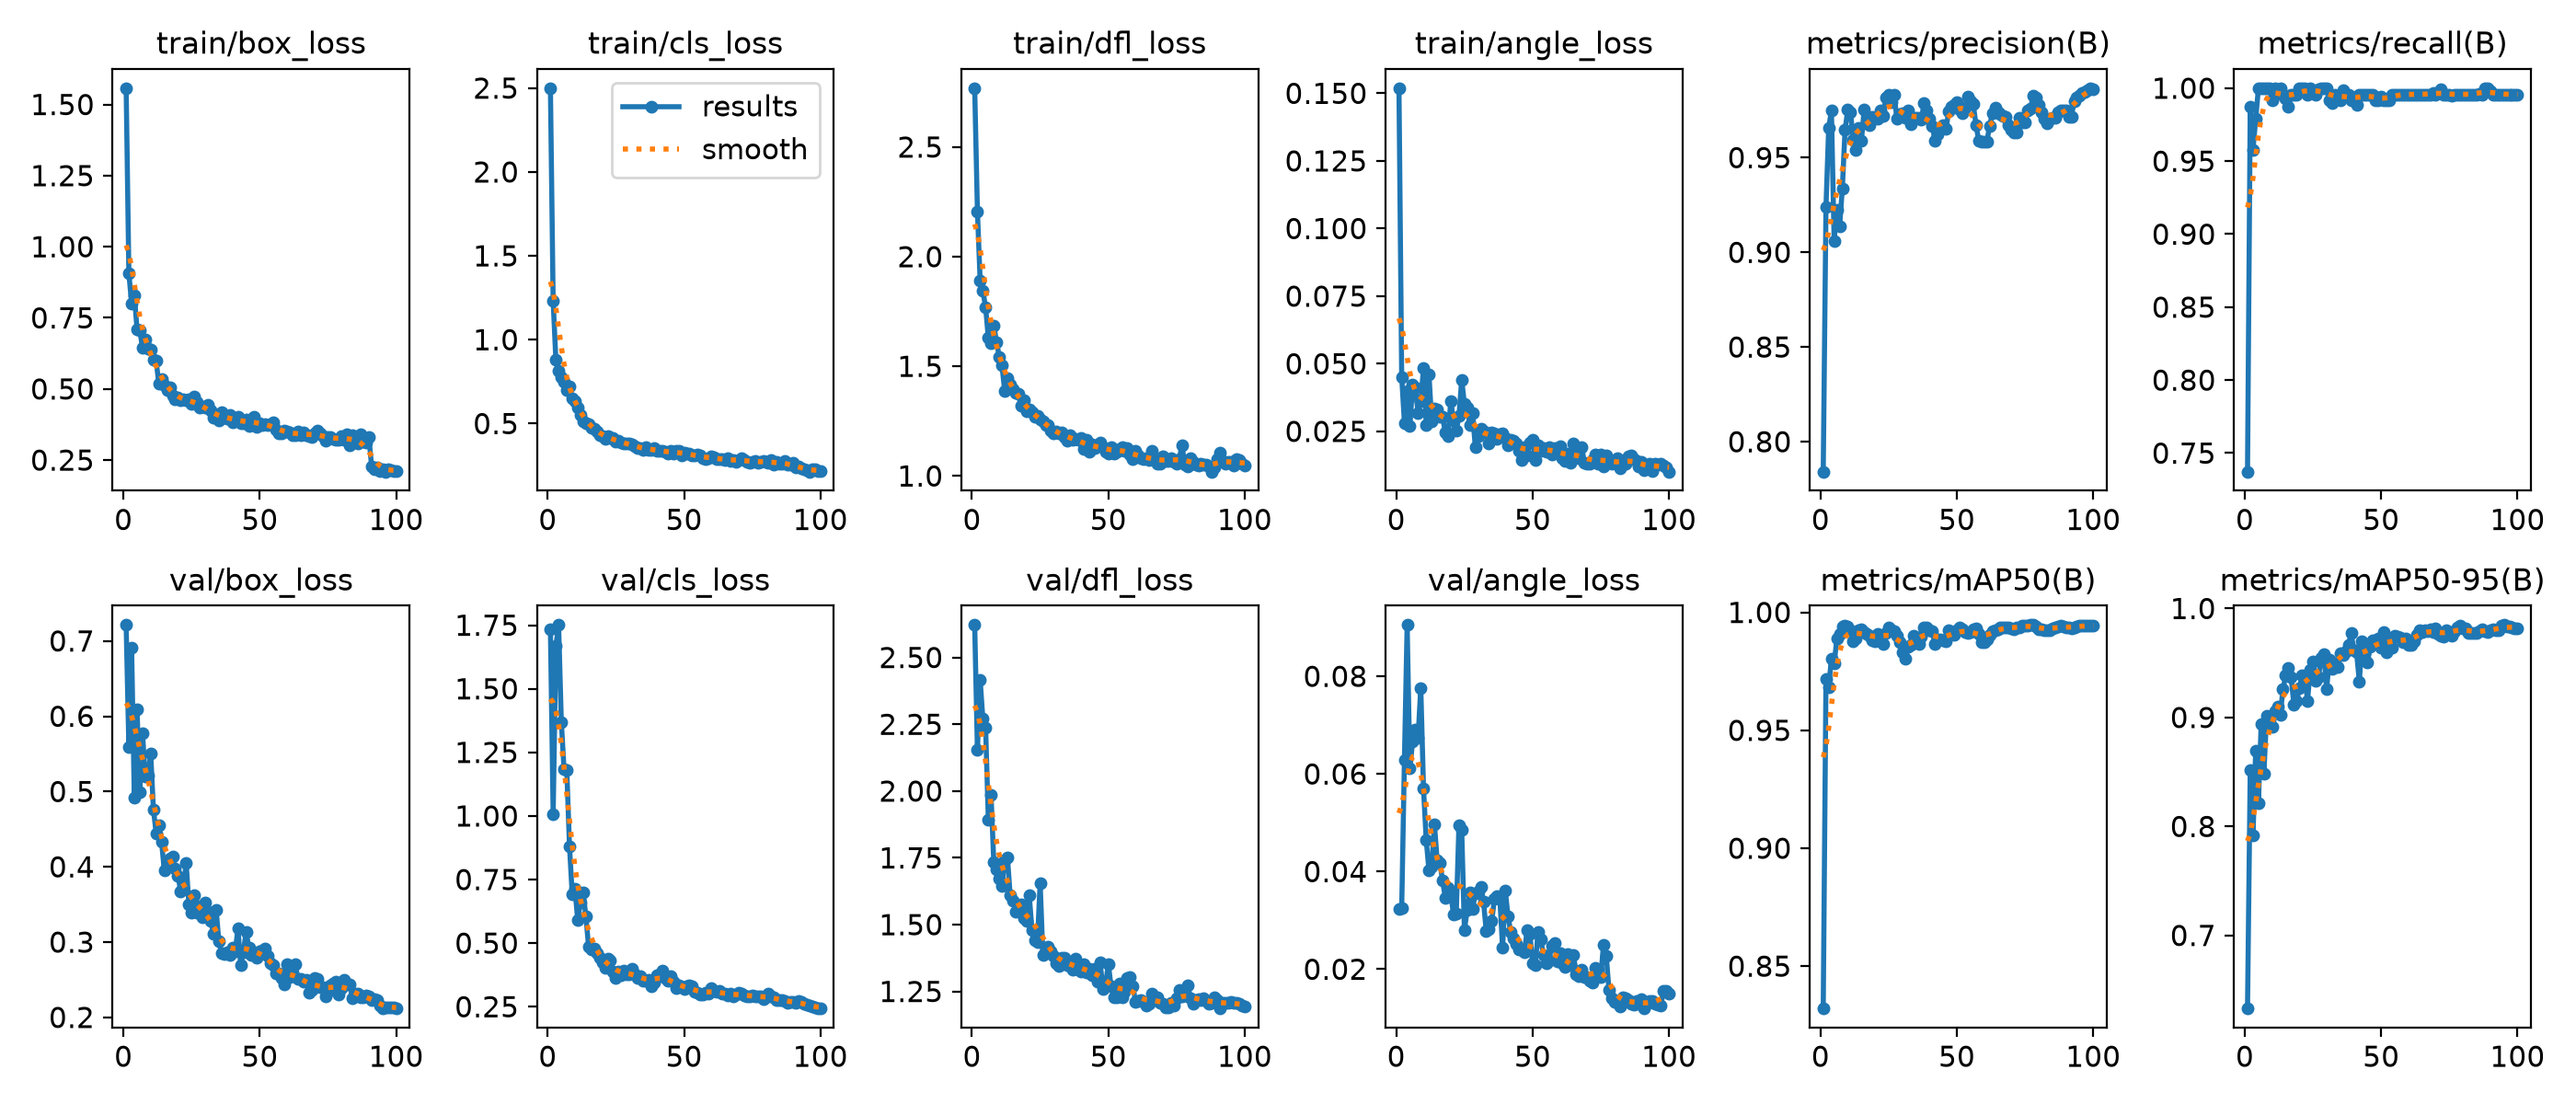


Lotes de validação (labels vs predições)
val_batch0_labels.jpg


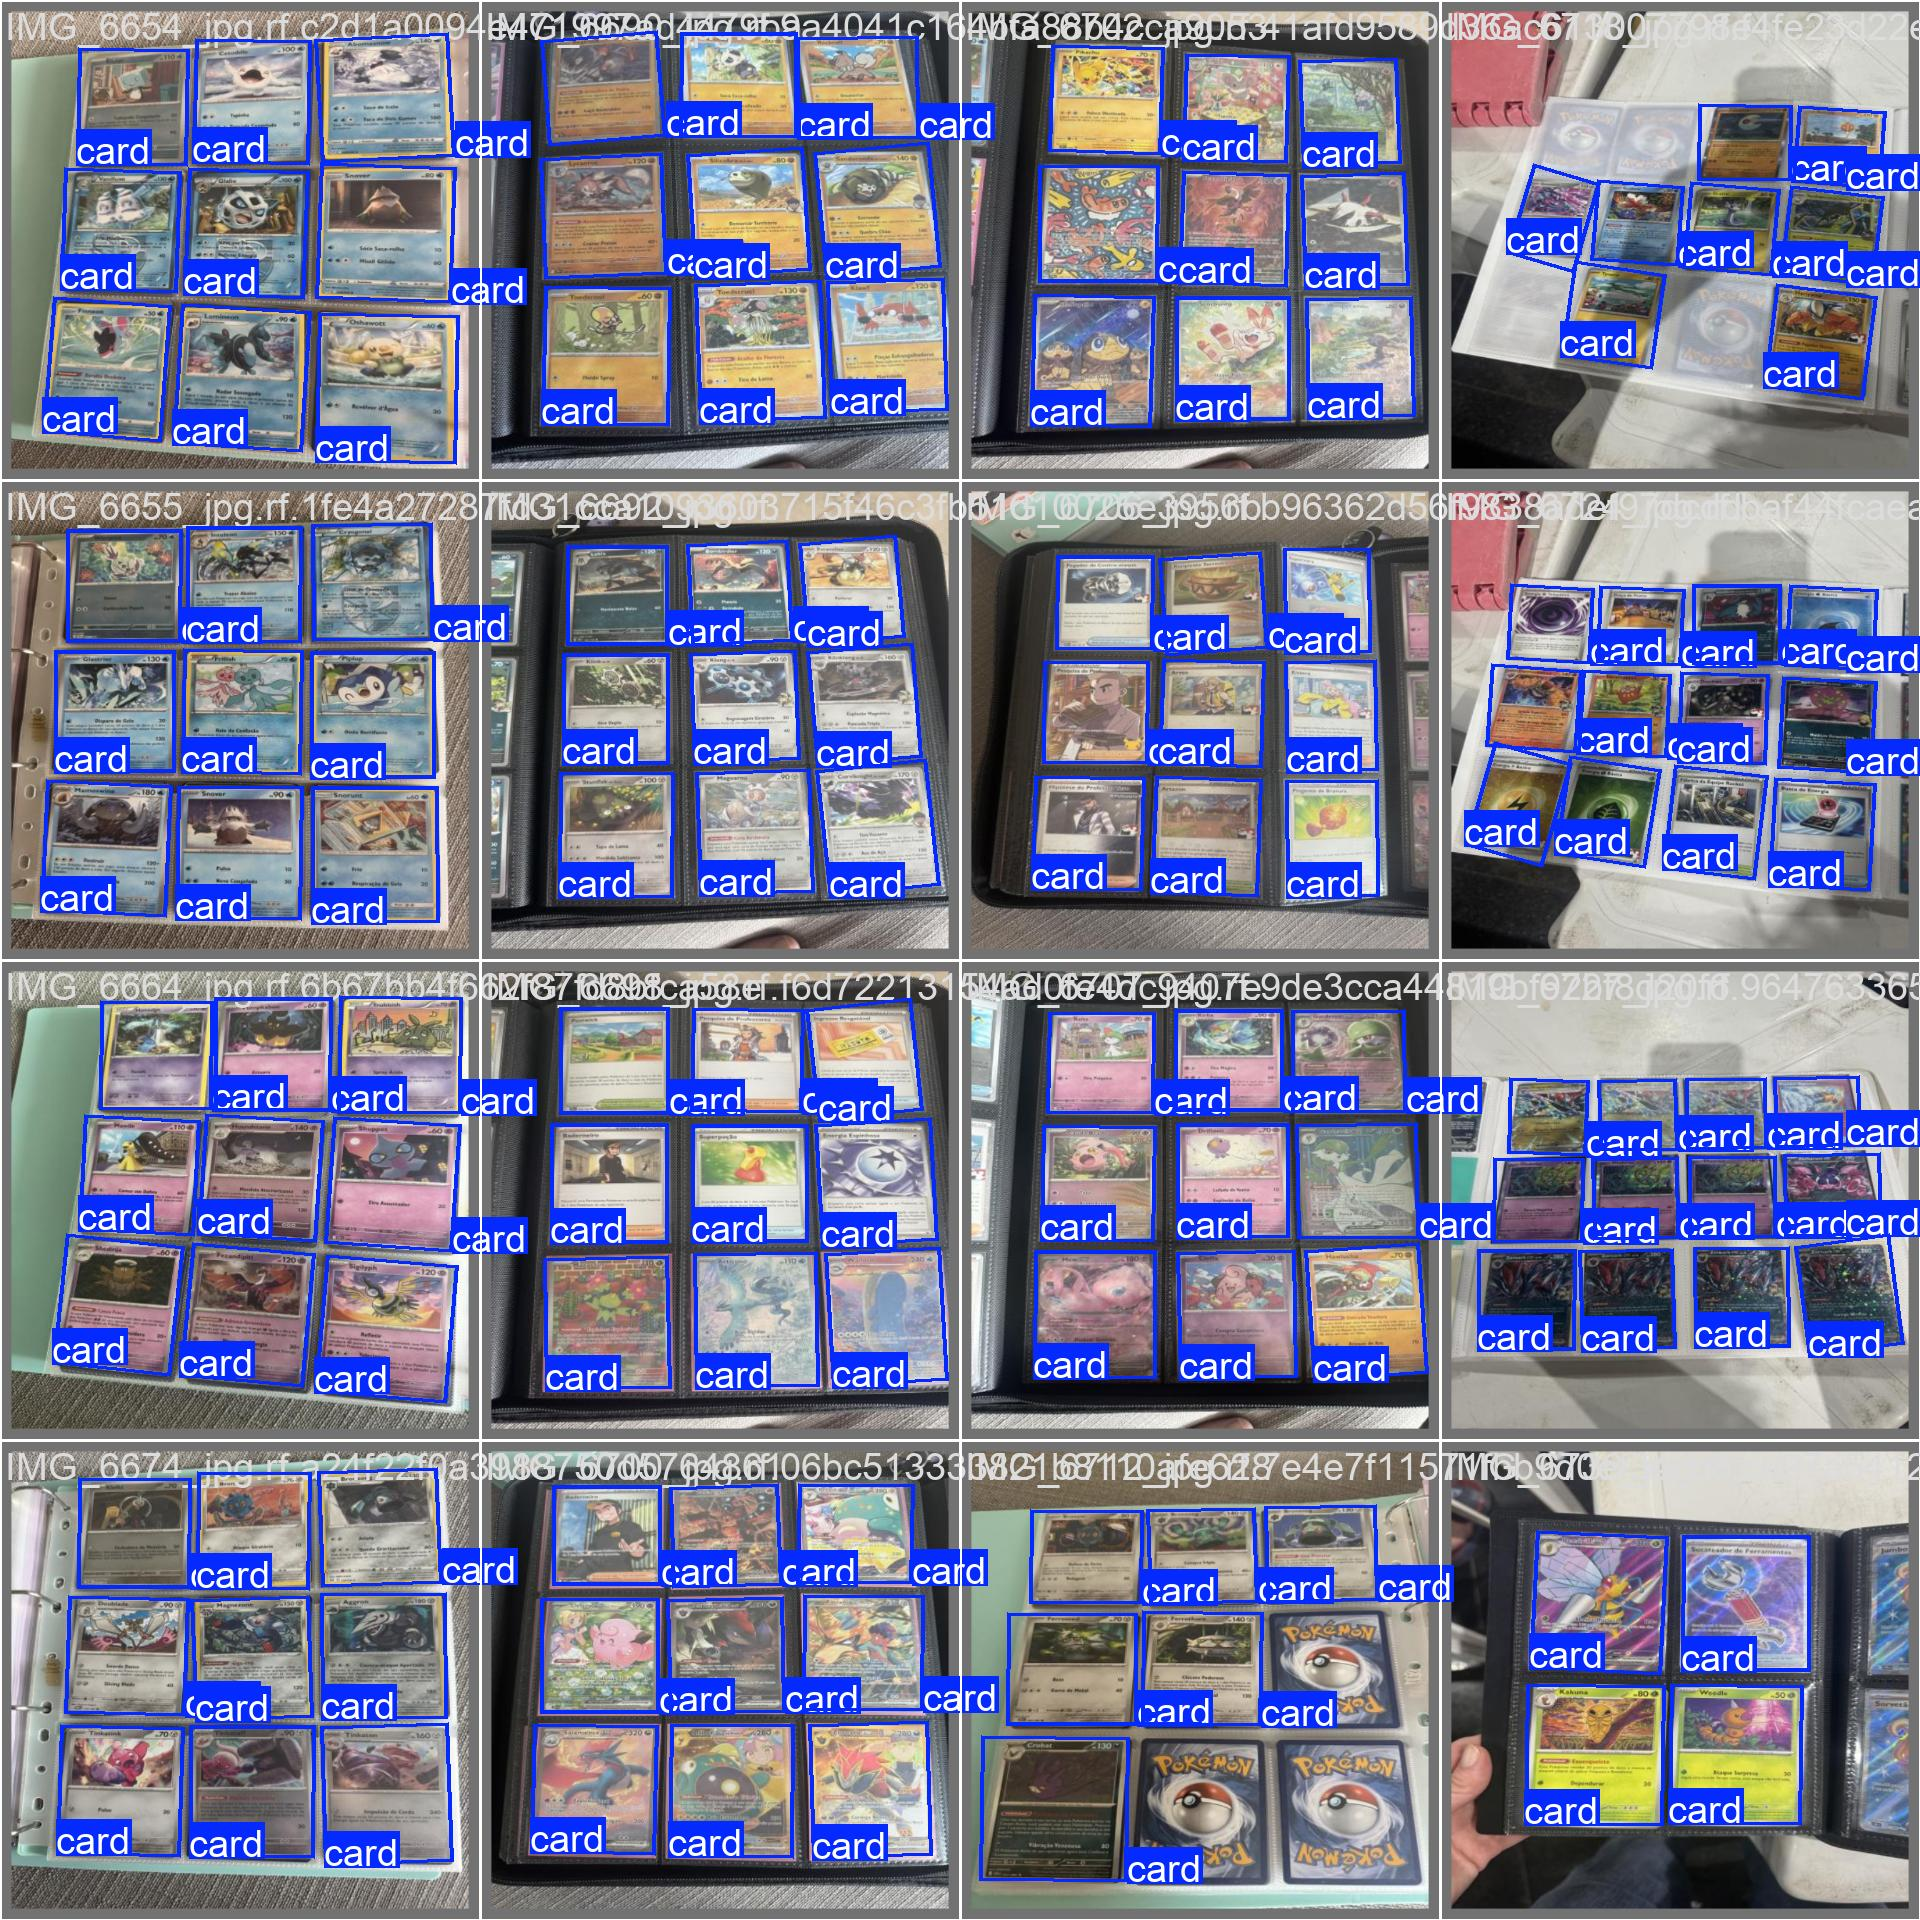

val_batch1_labels.jpg


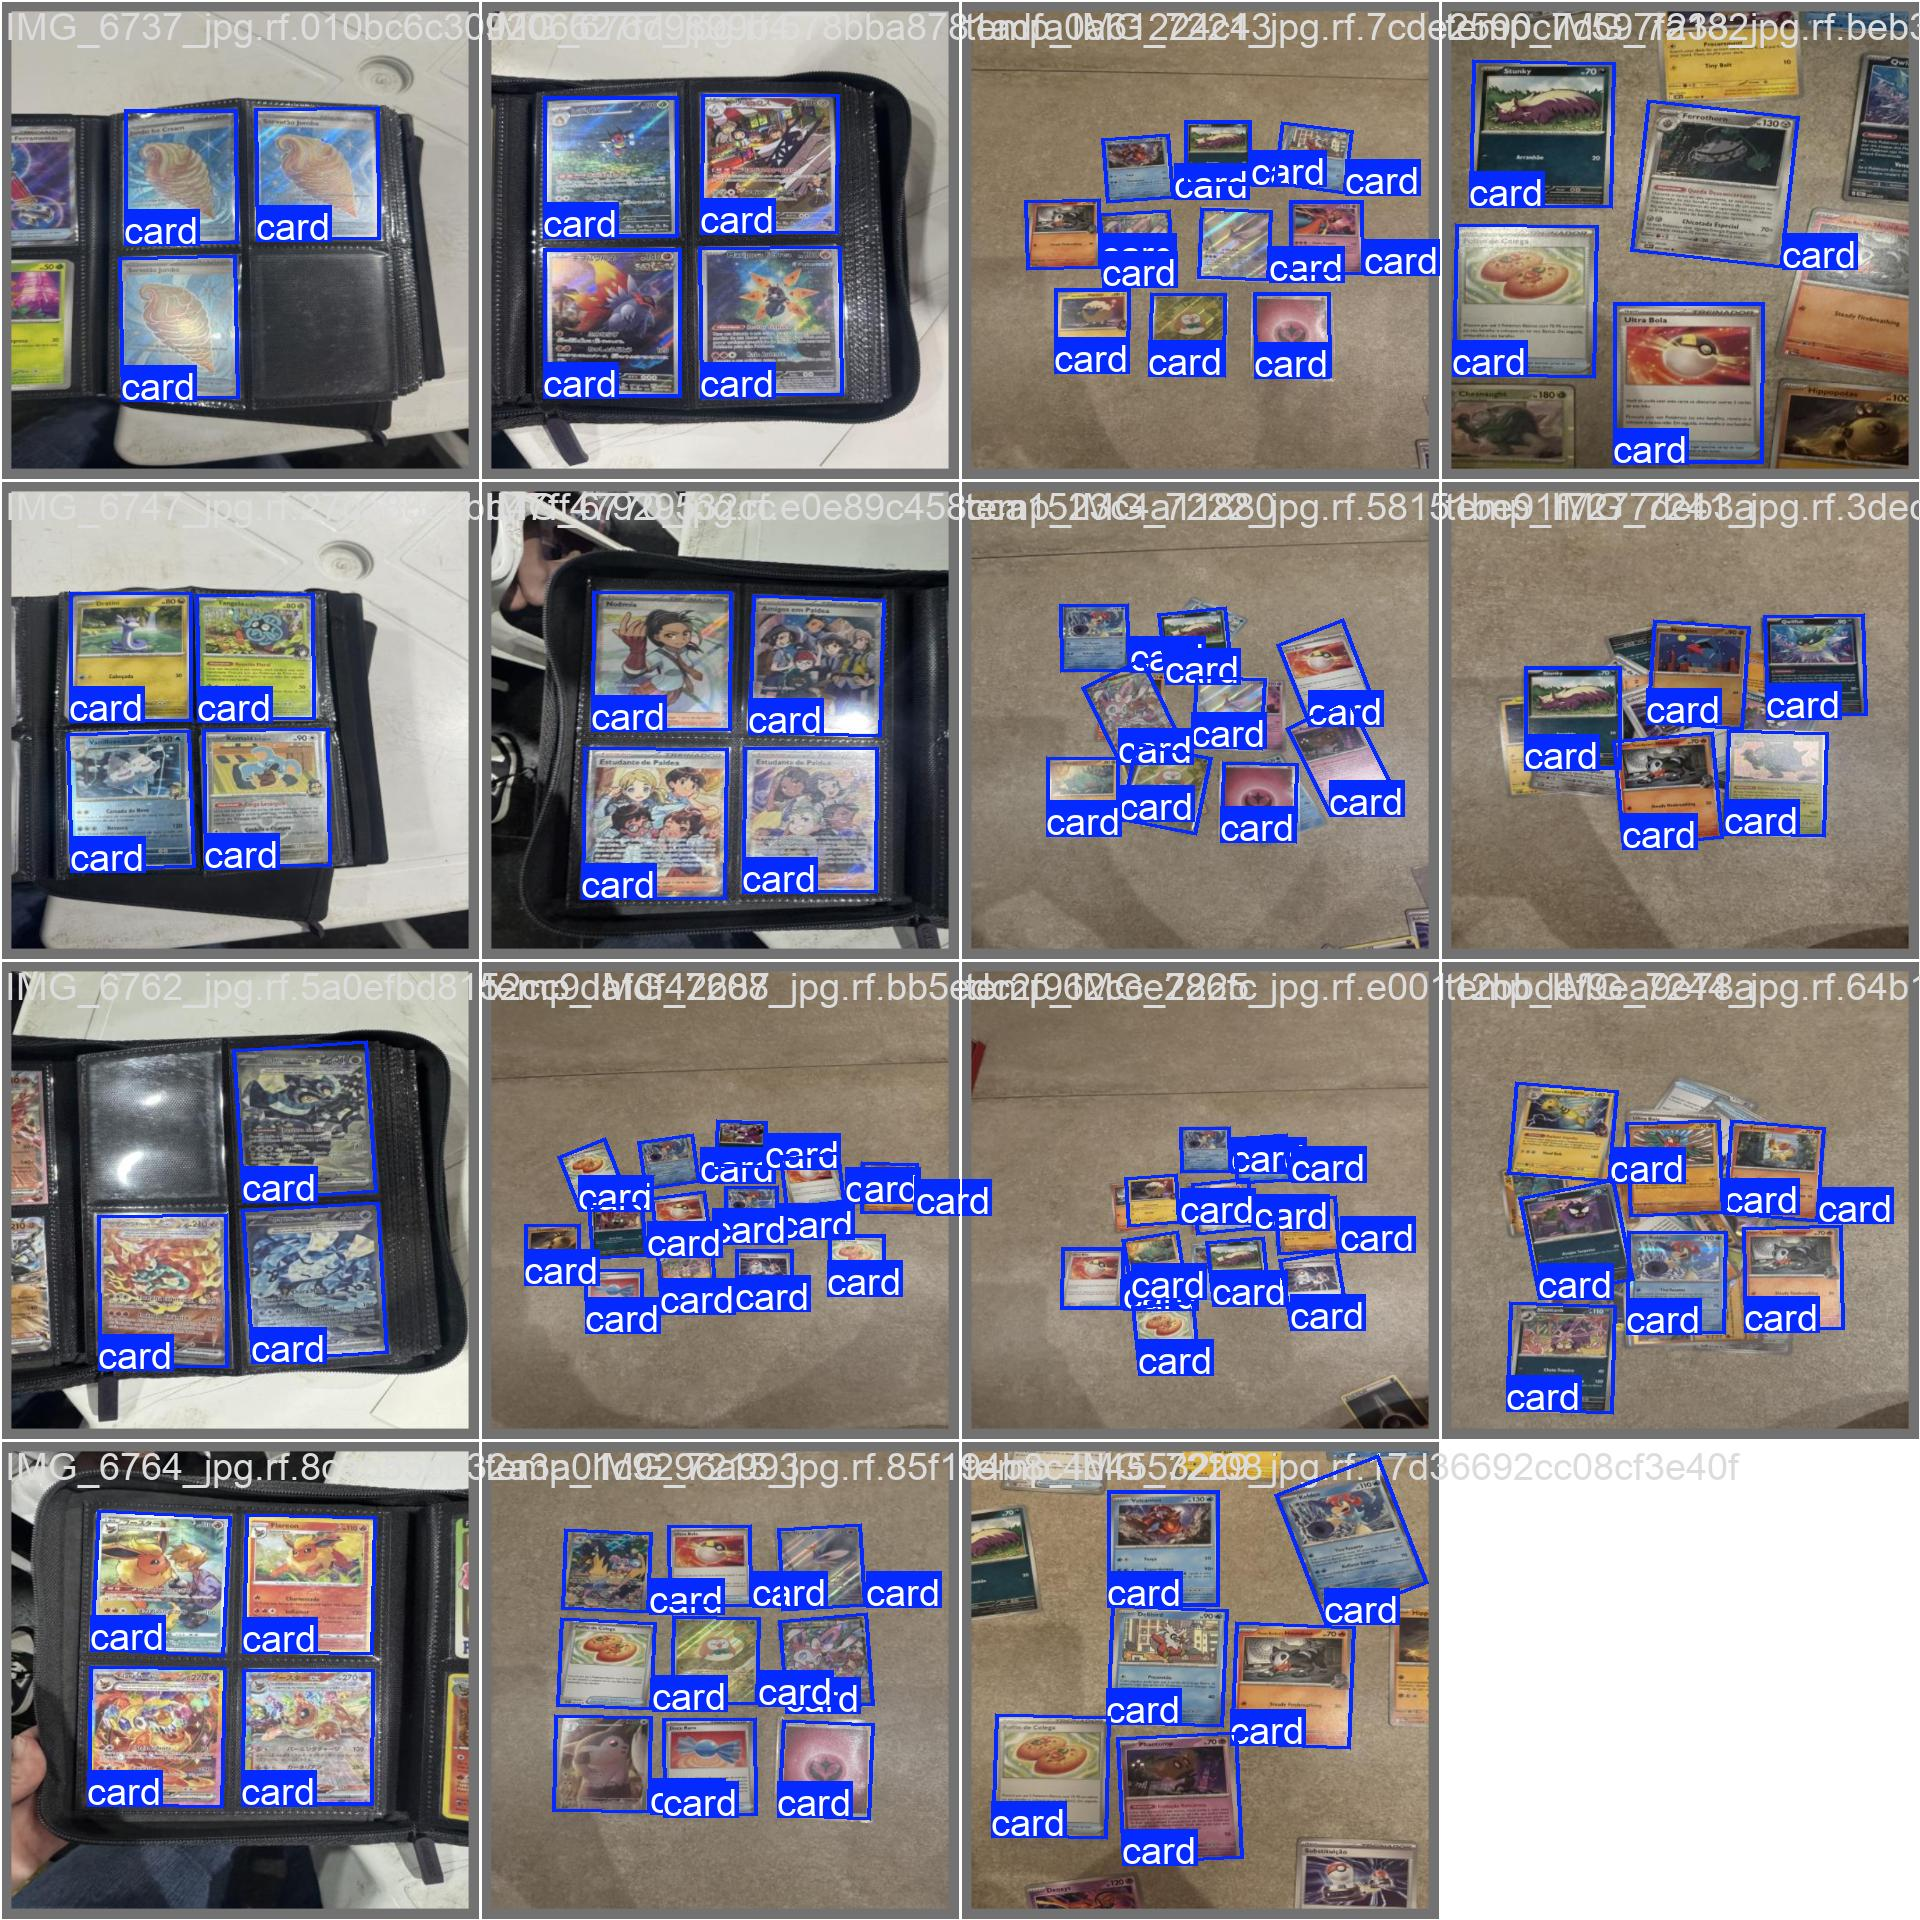

val_batch0_pred.jpg


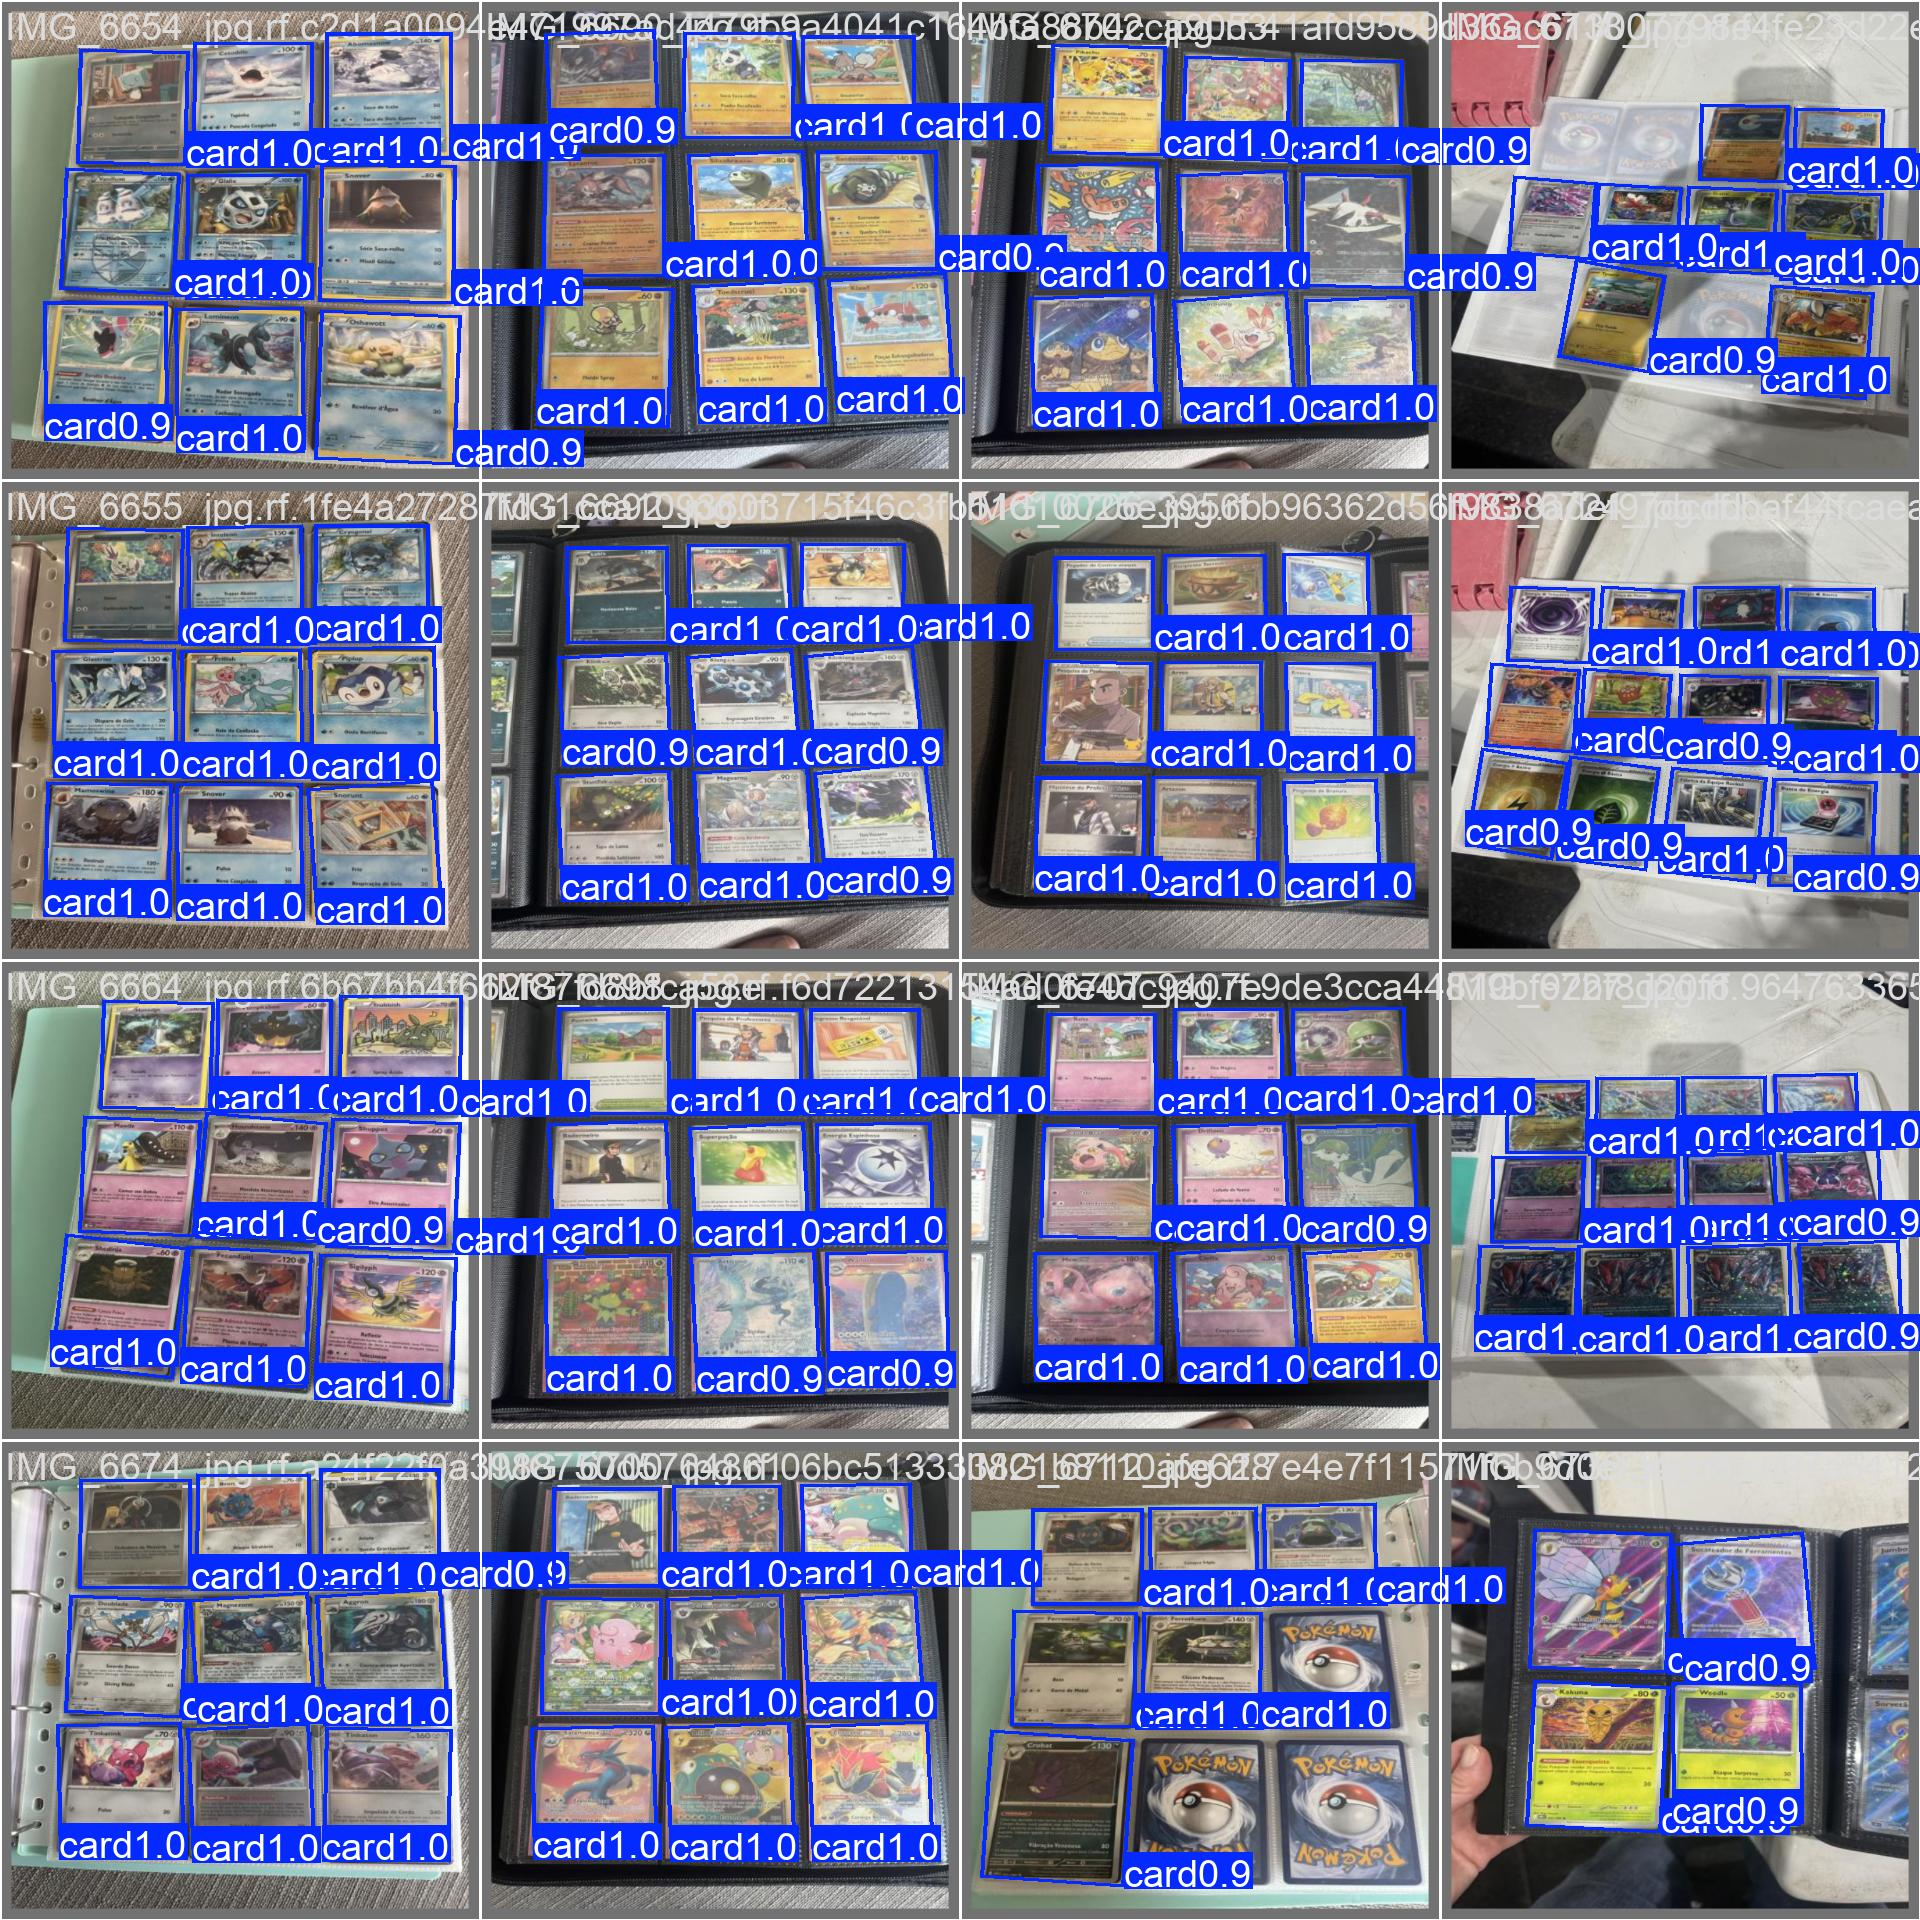

val_batch1_pred.jpg


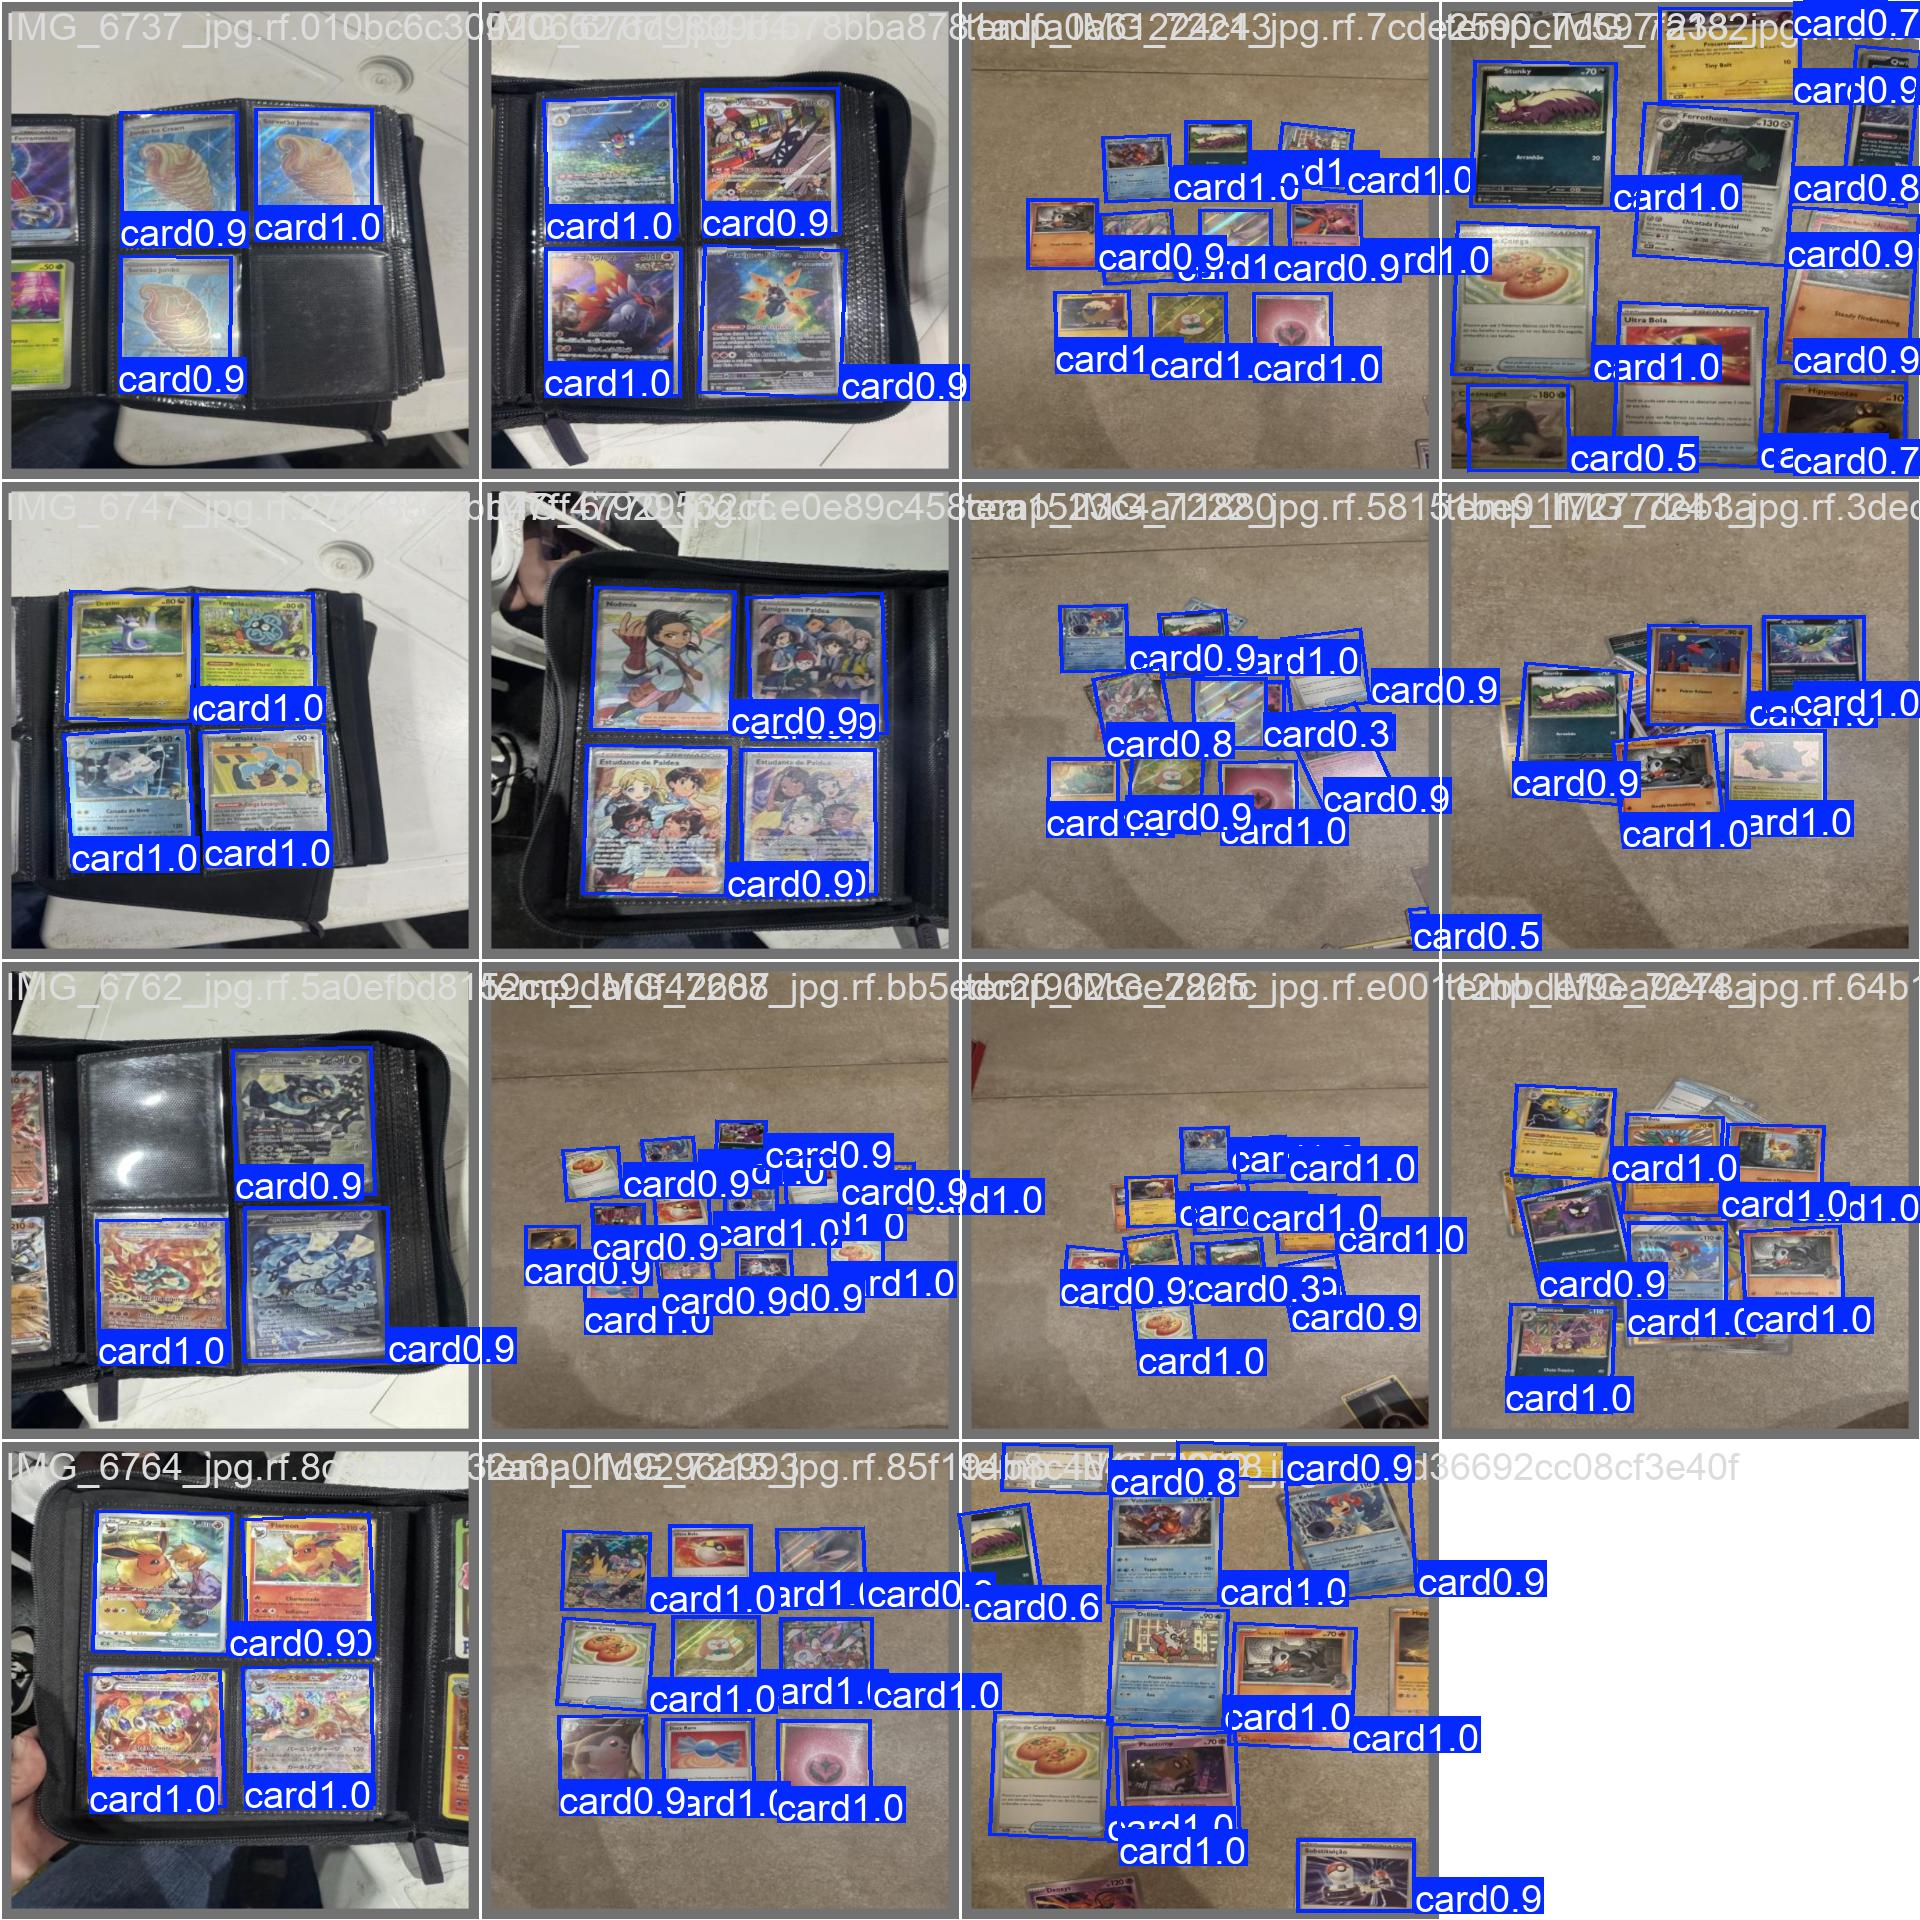

In [50]:
from IPython.display import Image as IPyImage, display as ipy_display

ARTIFACTS = [
    ("Matriz de confusão", "confusion_matrix.png"),
    ("Matriz de confusão (normalizada)", "confusion_matrix_normalized.png"),
    ("Curva F1 vs Confidence", "F1_curve.png"),
    ("Curva Precision–Recall", "PR_curve.png"),
    ("Curvas de treino (results.png)", "results.png"),
]
ARTIFACT_ALIASES = {
    "F1_curve.png": ["BoxF1_curve.png"],
    "PR_curve.png": ["BoxPR_curve.png"],
}


def find_artifact(run_dir: Path, filename: str) -> Path | None:
    names = [filename, *ARTIFACT_ALIASES.get(filename, [])]
    for name in names:
        direct = run_dir / name
        if direct.exists():
            return direct
        matches = sorted(run_dir.rglob(name))
        if matches:
            return matches[0]
    return None


print(f"Artefatos em: {RUN_DIR}\n")
for title, filename in ARTIFACTS:
    path = find_artifact(RUN_DIR, filename)
    if path is None:
        print(f"[ausente] {filename}")
        continue
    print(f"{title}  →  {path}")
    ipy_display(IPyImage(filename=str(path), width=720))


print("\nLotes de validação (labels vs predições)")
val_images = sorted(RUN_DIR.glob("val_batch*_labels.jpg")) + sorted(RUN_DIR.glob("val_batch*_pred.jpg"))
if not val_images:
    val_images = sorted(RUN_DIR.rglob("val_batch*.jpg"))

if not val_images:
    print("Nenhum lote de validação encontrado.")
else:
    for path in val_images:
        print(path.name)
        ipy_display(IPyImage(filename=str(path), width=720))


## 6. Renomeação dos pesos e exportação ONNX

1. Renomeia `runs/obb/obb-{VERSION}/weights/best.pt` → `obb-{VERSION}.pt`
2. Exporta o modelo final para ONNX como `obb-{VERSION}.onnx`


In [51]:
import shutil


def rename_best_weights(weights_dir: Path, experiment_name: str) -> Path:
    src = weights_dir / "best.pt"
    dst = weights_dir / f"{experiment_name}.pt"
    if dst.exists() and not src.exists():
        print(f"Pesos já renomeados: {dst}")
        return dst
    if not src.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {src}")
    if dst.exists():
        dst.unlink()
    src.rename(dst)
    print(f"Renomeado: {src.name} → {dst.name}")
    return dst


def export_onnx(pt_path: Path, experiment_name: str, imgsz: int, device: str) -> Path:
    export_model = YOLO(str(pt_path))
    produced = export_model.export(
        format="onnx",
        imgsz=imgsz,
        device=device,
        simplify=True,
        dynamic=False,
        opset=12,
    )
    produced_path = Path(str(produced))
    target = pt_path.with_name(f"{experiment_name}.onnx")

    if produced_path.resolve() != target.resolve():
        if target.exists():
            target.unlink()
        shutil.move(str(produced_path), str(target))

    print(f"ONNX exportado: {target}")
    return target


final_pt = rename_best_weights(WEIGHTS_DIR, EXPERIMENT_NAME)
final_onnx = export_onnx(final_pt, EXPERIMENT_NAME, IMGSZ, DEVICE)

print()
print("=" * 72)
print("Arquivos finais")
print("=" * 72)
for path in (final_pt, final_onnx, WEIGHTS_DIR / "last.pt"):
    if path.exists():
        size_mb = path.stat().st_size / 1024**2
        print(f"  {path.name:20s}  {size_mb:7.2f} MB  →  {path}")
    else:
        print(f"  {path.name:20s}  (ausente)")


Renomeado: best.pt → obb-v1.pt
Ultralytics 8.4.129  Python-3.14.7 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060, 8150MiB)
YOLOv8n-obb summary (fused): 82 layers, 3,077,414 parameters, 0 gradients, 8.3 GFLOPs

PyTorch: starting from 'C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\runs\obb\obb-v1\weights\obb-v1.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (6.4 MB)
requirements: Ultralytics requirements ['onnxruntime-gpu', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
   ---------------------------------------- 0.0/148.8 MB ? eta -:--:--
    --------------------------------------- 2.1/148.8 MB 11.9 MB/s eta 0:00:13
   - -------------------------------------- 4.7/148.8 MB 11.9 MB/s eta 0:00:13
   - -------------------------------------- 7.3/148.8 MB 11.9 MB/s eta 0:00:12
   -- ------------------------------------- 9.7/148.8 MB 11.9 MB/s eta 0:00:12
   --- ------------------------------------ 12.3/148.8 MB 11.8 MB/s eta 0:00:12
   --

## Uso rápido do modelo exportado

```python
from ultralytics import YOLO

model = YOLO("runs/obb/obb-v1/weights/obb-v1.pt")      # PyTorch
# model = YOLO("runs/obb/obb-v1/weights/obb-v1.onnx")  # ONNX

results = model.predict("dataset/test/images", save=True)
```

Para um novo experimento, altere `VERSION` no início do notebook (ex.: `"v2"`) e execute novamente. Os artefatos serão gravados em `runs/obb/obb-v2/`.
